# Semestral Project - Credit Card Customer Segmentation 

**Objective:** Prepare a credit card behavioral dataset for clustering models by performing thorough exploratory data analysis, data cleaning, feature engineering, scaling, and dimensionality reduction.

**Dataset:** ~9,000 active credit card holders observed over 6 months, described by 18 behavioral variables (balances, purchases, cash advances, payments, credit limits, tenures, and frequency scores).

**Developers** Filip Guoth, Richard Šimo

---

In [ ]:
import piplite
await piplite.install(["pandas", "numpy", "matplotlib", "seaborn"])

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Consistent plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

# ── Load data robustly ────────────────────────────────────────────────────────
# The provided CSV has:
#   - an empty first column,
#   - a group header row containing "FREQUENCY",
#   - the real column names on the next row,
#   - decimal commas instead of decimal dots.
raw = pd.read_csv(
    "credit_cards_semestral_project.csv",
    sep=";",
    header=None,
    dtype=str
)

# Remove fully empty columns, e.g. the first unnamed empty column
raw = raw.dropna(axis=1, how="all")

# Find the row that contains the real header
header_matches = raw.apply(
    lambda row: row.astype(str).str.strip().str.upper().eq("CUST_ID").any(),
    axis=1
)

if not header_matches.any():
    raise ValueError("Could not find the real header row containing CUST_ID.")

header_row = header_matches[header_matches].index[0]

# Data starts after the real header row
df = raw.iloc[header_row + 1:].copy()

# Correct column names. The last five columns are frequency variables whose
# original names are duplicated in the CSV header.
expected_columns = [
    "CUST_ID",
    "BALANCE",
    "PURCHASES",
    "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE",
    "CASH_ADVANCE_TRX",
    "PURCHASES_TRX",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "MINIMUM_PAYMENTS",
    "PRC_FULL_PAYMENT",
    "BALANCE_FREQUENCY",
    "PURCHASES_FREQUENCY",
    "ONEOFF_PURCHASES_FREQUENCY",
    "PURCHASES_INSTALLMENTS_FREQUENCY",
    "CASH_ADVANCE_FREQUENCY",
    "TENURE"
]

if df.shape[1] != len(expected_columns):
    raise ValueError(
        f"Unexpected number of columns after loading: {df.shape[1]}. "
        f"Expected {len(expected_columns)}."
    )

df.columns = expected_columns

# Remove empty rows, for example the blank row after the header
df = df.dropna(how="all")

# Remove rows where customer ID is missing
df = df[df["CUST_ID"].notna()].copy()

# Convert all non-ID columns to numeric
for col in df.columns:
    if col != "CUST_ID":
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Keep a correctly parsed raw copy for later cleaning steps
df_raw = df.copy()

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

display(df.head())


Dataset loaded successfully.
Shape: (9845, 18)

Columns:
['CUST_ID', 'BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'BALANCE_FREQUENCY', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'TENURE']

Data types:
CUST_ID                                 str
BALANCE                             float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
CASH_ADVANCE_TRX                    float64
PURCHASES_TRX                       float64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
BALANCE_FREQUENCY                   float64
PURCHASES

,CUST_ID,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,BALANCE_FREQUENCY,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,TENURE
17,C17342,27.625906,234.48,0.00,234.48,0.000000,0.0,12.0,2500.0,109.281131,93.624640,0.00,0.818182,1.000000,0.000000,1.000000,0.000000,12.0
18,C13053,8791.161142,0.00,0.00,0.00,3706.755143,4.0,0.0,12000.0,2244.627566,2916.278944,0.00,1.000000,0.000000,0.000000,0.000000,0.333333,12.0
19,C11723,165.808096,981.19,823.39,157.80,0.000000,0.0,16.0,9000.0,672.446893,105.350665,0.25,0.714286,0.714286,0.571429,0.285714,0.000000,7.0
20,C13717,4157.933876,929.20,631.40,297.80,2592.238013,8.0,12.0,8000.0,934.634439,1076.539881,0.00,1.000000,0.583333,0.333333,0.250000,0.583333,12.0
21,C11464,19.945714,170.00,170.00,0.00,0.000000,0.0,1.0,6500.0,734.613034,166.057617,1.00,0.272727,0.083333,0.083333,0.000000,0.000000,12.0


---
## Exploratory Data Analysis

Before touching the data, we need to understand it thoroughly. EDA reveals the raw state of the dataset — its structure, quality issues, and distributional properties — and motivates every cleaning and transformation decision made in the pipeline that follows.


### 1 · Dataset Overview

We start by checking the shape of the dataset, the names and types of all columns, and the first few rows to get an initial feel for the data.

In [3]:
print('─── Shape ───────────────────────────────')
print(f'  Rows   : {df.shape[0]:,}')
print(f'  Columns: {df.shape[1]}')

print('\n─── Column names ────────────────────────')
for col in df.columns:
    print(f'  {col}')

print('\n─── First 5 rows ────────────────────────')
df.head()

─── Shape ───────────────────────────────
  Rows   : 9,845
  Columns: 18

─── Column names ────────────────────────
  CUST_ID
  BALANCE
  PURCHASES
  ONEOFF_PURCHASES
  INSTALLMENTS_PURCHASES
  CASH_ADVANCE
  CASH_ADVANCE_TRX
  PURCHASES_TRX
  CREDIT_LIMIT
  PAYMENTS
  MINIMUM_PAYMENTS
  PRC_FULL_PAYMENT
  BALANCE_FREQUENCY
  PURCHASES_FREQUENCY
  ONEOFF_PURCHASES_FREQUENCY
  PURCHASES_INSTALLMENTS_FREQUENCY
  CASH_ADVANCE_FREQUENCY
  TENURE

─── First 5 rows ────────────────────────


,CUST_ID,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,BALANCE_FREQUENCY,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,TENURE
17,C17342,27.625906,234.48,0.00,234.48,0.000000,0.0,12.0,2500.0,109.281131,93.624640,0.00,0.818182,1.000000,0.000000,1.000000,0.000000,12.0
18,C13053,8791.161142,0.00,0.00,0.00,3706.755143,4.0,0.0,12000.0,2244.627566,2916.278944,0.00,1.000000,0.000000,0.000000,0.000000,0.333333,12.0
19,C11723,165.808096,981.19,823.39,157.80,0.000000,0.0,16.0,9000.0,672.446893,105.350665,0.25,0.714286,0.714286,0.571429,0.285714,0.000000,7.0
20,C13717,4157.933876,929.20,631.40,297.80,2592.238013,8.0,12.0,8000.0,934.634439,1076.539881,0.00,1.000000,0.583333,0.333333,0.250000,0.583333,12.0
21,C11464,19.945714,170.00,170.00,0.00,0.000000,0.0,1.0,6500.0,734.613034,166.057617,1.00,0.272727,0.083333,0.083333,0.000000,0.000000,12.0


In [4]:
# Data types and non-null counts per column
print('─── Data types & non-null counts ────────')
df.info()

─── Data types & non-null counts ────────
<class 'pandas.DataFrame'>
RangeIndex: 9845 entries, 17 to 9861
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           9845 non-null   str    
 1   BALANCE                           9839 non-null   float64
 2   PURCHASES                         9837 non-null   float64
 3   ONEOFF_PURCHASES                  9833 non-null   float64
 4   INSTALLMENTS_PURCHASES            9840 non-null   float64
 5   CASH_ADVANCE                      9837 non-null   float64
 6   CASH_ADVANCE_TRX                  9840 non-null   float64
 7   PURCHASES_TRX                     9841 non-null   float64
 8   CREDIT_LIMIT                      9838 non-null   float64
 9   PAYMENTS                          9836 non-null   float64
 10  MINIMUM_PAYMENTS                  9495 non-null   float64
 11  PRC_FULL_PAYMENT                  983

### 2 · Missing Values Analysis

Missing values are a common problem in behavioral datasets. They can appear because of system errors, customers who never used certain features (e.g., never paid in installments), or simply incomplete records. We quantify them before deciding on an imputation strategy.

Columns with missing values:


,Missing Count,Missing %
MINIMUM_PAYMENTS,350,3.56
ONEOFF_PURCHASES,12,0.12
ONEOFF_PURCHASES_FREQUENCY,11,0.11
PAYMENTS,9,0.09
TENURE,9,0.09
CASH_ADVANCE,8,0.08
PURCHASES,8,0.08
CREDIT_LIMIT,7,0.07
PRC_FULL_PAYMENT,7,0.07
BALANCE_FREQUENCY,7,0.07


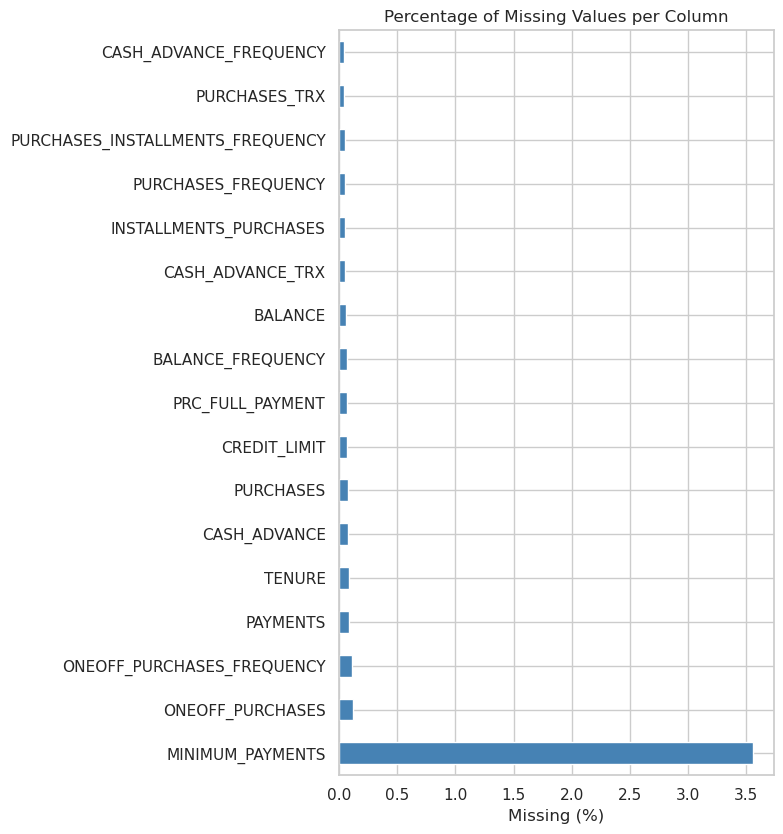

In [5]:
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing %'     : missing_pct
}).sort_values('Missing Count', ascending=False)

# Show only columns that actually have missing values
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('No missing values found.')
else:
    print('Columns with missing values:')
    display(missing_df)

    # Visual bar chart
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing_df) * 0.5)))
    missing_df['Missing %'].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Percentage of Missing Values per Column')
    plt.tight_layout()
    plt.show()

### 3 · Duplicate Rows Check

Duplicate rows would give disproportionate weight to certain customers during distance-based clustering, artificially pulling centroids towards repeated observations. We count them now and will remove them during cleaning.

In [6]:
n_duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {n_duplicates} ({n_duplicates / len(df) * 100:.2f}% of dataset)')

Number of duplicate rows: 895 (9.09% of dataset)


### 4 · Invalid Values Check (−1 placeholder)

A negative balance or credit limit is not meaningful in this context, so we scan every column for cells equal to `-1` and count how many rows are affected.

In [7]:
# Check each numeric column for -1 values
numeric_cols = df.select_dtypes(include='number').columns
invalid_mask = (df[numeric_cols] == -1).any(axis=1)
n_invalid = invalid_mask.sum()

print(f'Rows containing at least one value equal to -1: {n_invalid}')

# Show which columns contain -1 values
cols_with_minus1 = (df[numeric_cols] == -1).sum()
cols_with_minus1 = cols_with_minus1[cols_with_minus1 > 0]
if not cols_with_minus1.empty:
    print('\nBreakdown by column:')
    print(cols_with_minus1.to_string())

Rows containing at least one value equal to -1: 11

Breakdown by column:
BALANCE                             2
PURCHASES                           2
ONEOFF_PURCHASES                    1
MINIMUM_PAYMENTS                    2
BALANCE_FREQUENCY                   1
ONEOFF_PURCHASES_FREQUENCY          2
PURCHASES_INSTALLMENTS_FREQUENCY    1


### 5 · Descriptive Statistics

Summary statistics provide a quick view of the central tendency and spread of every numerical column. Wide gaps between the mean and the median, or very large standard deviations, are first indicators of skewed distributions or outliers.

In [8]:
pd.set_option('display.float_format', '{:,.4f}'.format)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,"9,839.0000","1,564.7043","2,085.8901",-1.0000,128.0836,872.0711,"2,045.9241","19,043.1386"
PURCHASES,"9,837.0000","1,019.2692","2,196.1724",-1.0000,39.5400,365.9000,"1,122.1700","49,039.5700"
ONEOFF_PURCHASES,"9,833.0000",604.7882,"1,726.7262",-1.0000,0.0000,39.8000,590.8000,"40,761.2500"
INSTALLMENTS_PURCHASES,"9,840.0000",414.8209,914.0891,0.0000,0.0000,88.9800,473.6250,"22,500.0000"
CASH_ADVANCE,"9,837.0000",966.4401,"2,073.0920",0.0000,0.0000,0.0000,"1,099.4417","47,137.2118"
CASH_ADVANCE_TRX,"9,840.0000",3.2239,6.7315,0.0000,0.0000,0.0000,4.0000,123.0000
PURCHASES_TRX,"9,841.0000",14.8254,25.1056,0.0000,1.0000,7.0000,17.0000,358.0000
CREDIT_LIMIT,"9,838.0000","4,496.7522","3,640.4969",50.0000,"1,500.0000","3,000.0000","6,500.0000","30,000.0000"
PAYMENTS,"9,836.0000","1,736.7159","2,888.5745",0.0000,384.0089,864.4996,"1,907.9120","50,721.4834"
MINIMUM_PAYMENTS,"9,495.0000",861.7551,"2,328.4426",-1.0000,169.0053,310.7127,825.7716,"76,406.2075"


### 6 · Distribution Analysis — Amount-Based Columns

Histograms let us visualise the shape of each monetary variable's distribution. In behavioral financial data, it is extremely common to see **heavy right skew**: most customers have low values, but a small number of high-spenders or high-balance holders pull the tail far to the right. This skew violates the assumptions of K-Means (which relies on Euclidean distance) and that is why we will use the log transformation later.

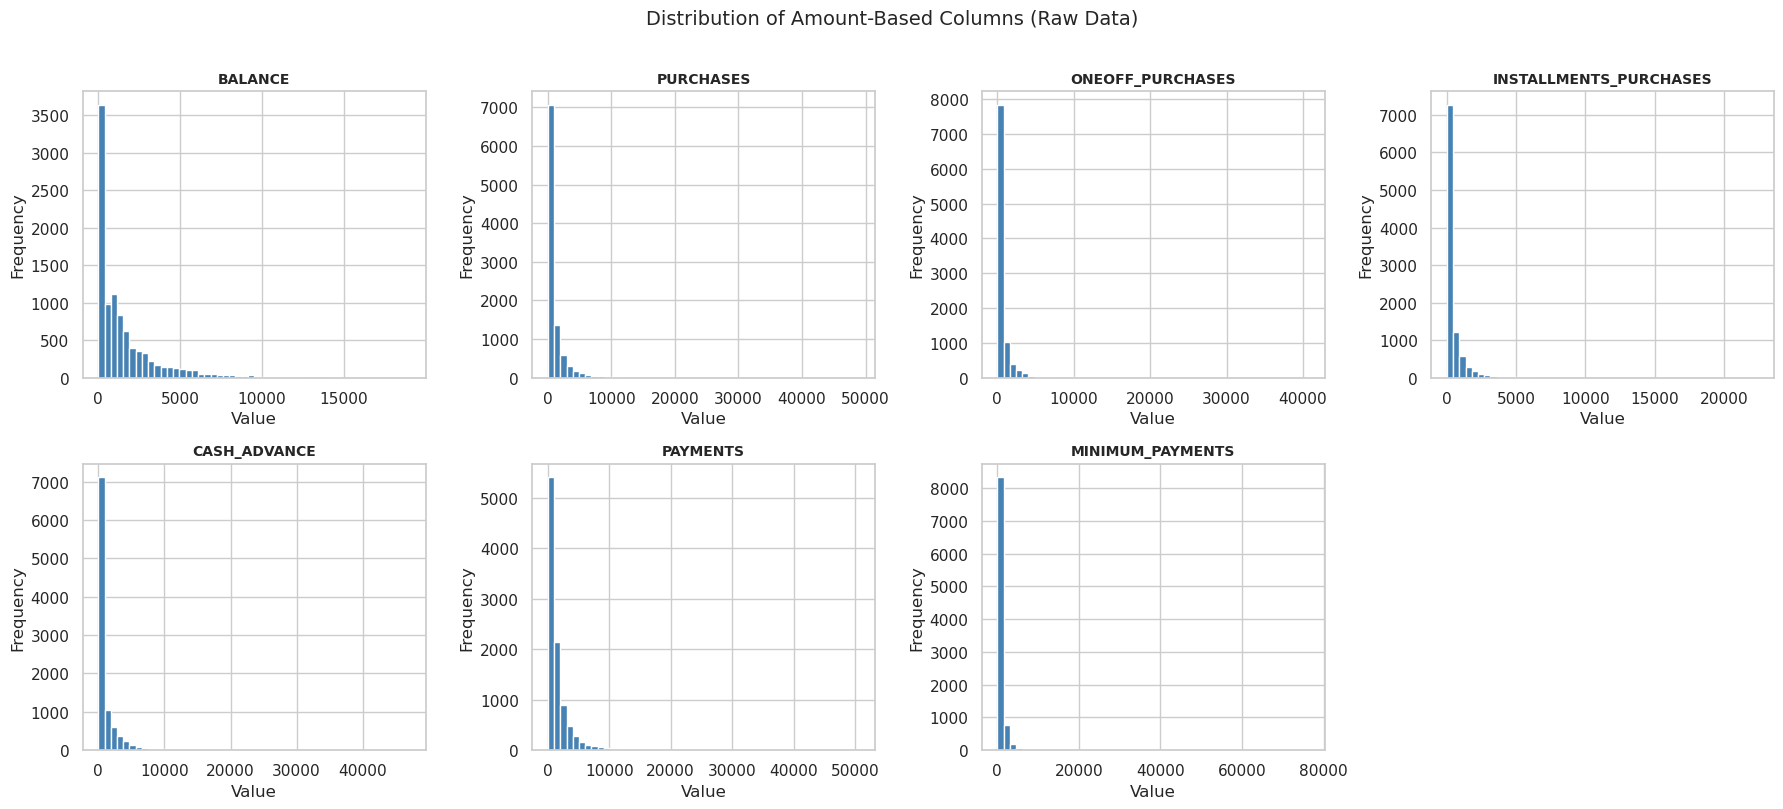

In [9]:
amount_cols = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES',
               'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
               'PAYMENTS', 'MINIMUM_PAYMENTS']

# Keep only columns that exist in this particular file
amount_cols = [c for c in amount_cols if c in df.columns]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(amount_cols):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide any unused subplot panels
for j in range(len(amount_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of Amount-Based Columns (Raw Data)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 7 · Outlier Inspection — Boxplots

Boxplots highlight extreme values more explicitly than histograms. Points beyond the whiskers (1.5× IQR) are flagged as statistical outliers. While we do **not** remove outliers blindly (they may represent a genuinely distinct customer segment), we need to know their extent because they severely inflate Euclidean distances and can collapse K-Means centroids into a small region of feature space.

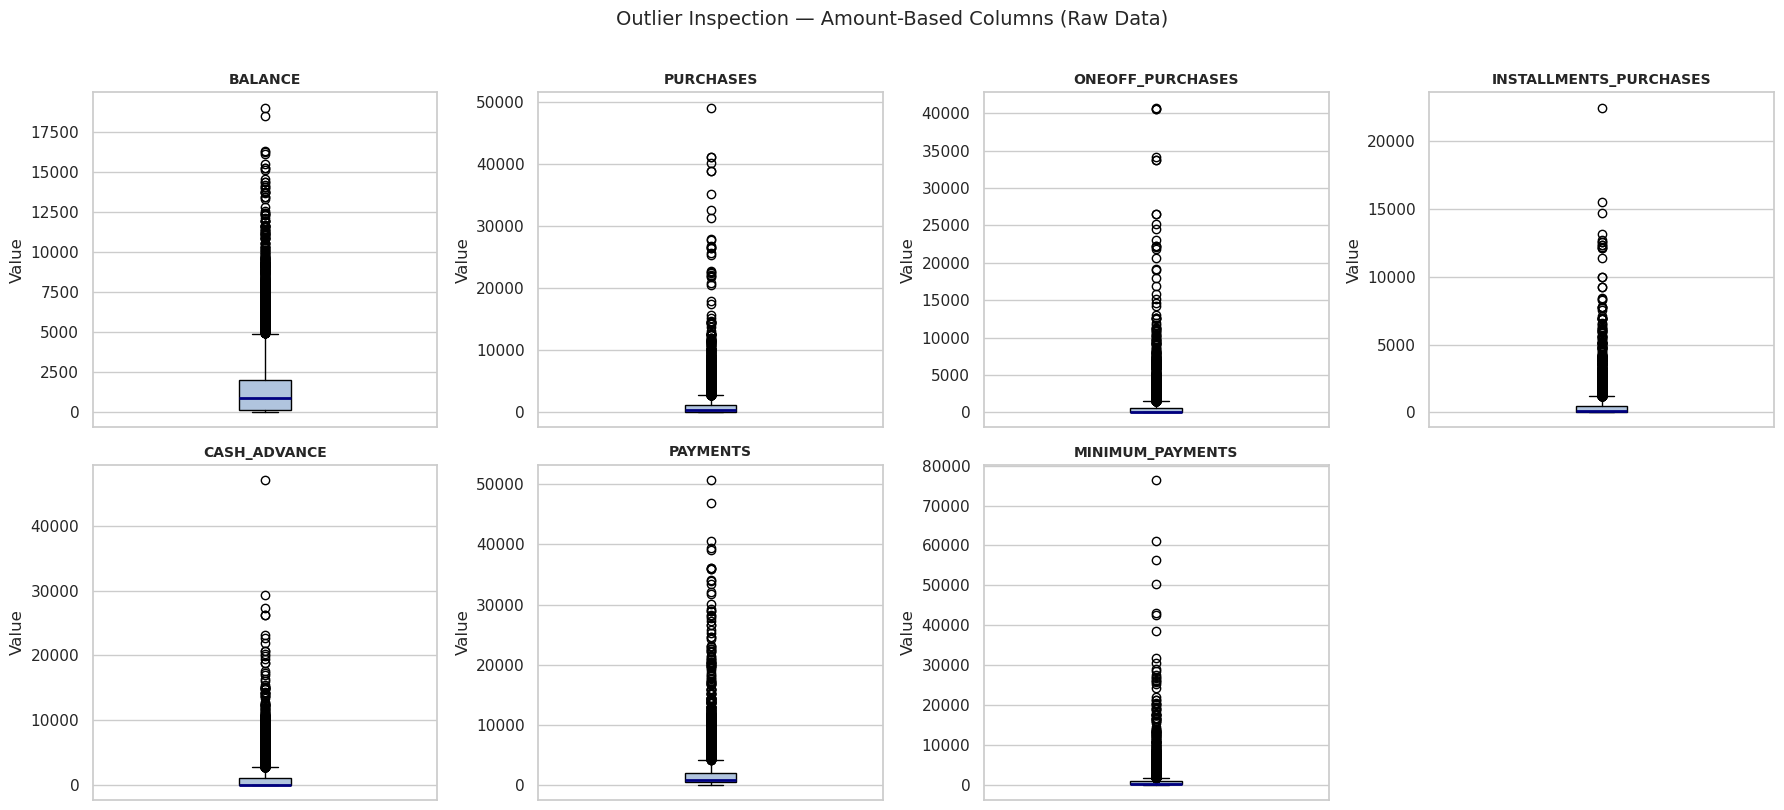

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(amount_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue'),
                    medianprops=dict(color='navy', linewidth=2))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].set_xticks([])

for j in range(len(amount_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Outlier Inspection — Amount-Based Columns (Raw Data)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 8 · Frequency Columns Inspection

All columns containing the word `FREQUENCY` should express a normalised score on the `[0, 1]` scale by design. We verify this assumption here. Any values above 1 are data quality issues that must be capped to maintain the intended scale.

In [11]:
freq_cols = [c for c in df.columns if 'FREQUENCY' in c.upper()]
print(f'Frequency columns found ({len(freq_cols)}): {freq_cols}\n')

# Convert frequency columns to numeric
for col in freq_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

freq_stats = df[freq_cols].agg(['min', 'max', 'nunique'])

for col in freq_cols:
    unique_vals = sorted(df[col].dropna().unique())

    print(f'{col}:')
    print(
        f'  min={df[col].min():.4f}, max={df[col].max():.4f}, '
        f'unique values ({len(unique_vals)}): {unique_vals[:10]}'
        f'{" ..." if len(unique_vals) > 10 else ""}'
    )

    if df[col].max() > 1:
        n_above = (df[col] > 1).sum()
        print(f'  ⚠️  {n_above} values ABOVE 1 — need capping!')

    print()

Frequency columns found (5): ['BALANCE_FREQUENCY', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY']

BALANCE_FREQUENCY:
  min=-1.0000, max=1.0000, unique values (44): [np.float64(-1.0), np.float64(0.0), np.float64(0.090909), np.float64(0.1), np.float64(0.111111), np.float64(0.125), np.float64(0.142857), np.float64(0.166667), np.float64(0.181818), np.float64(0.2)] ...

PURCHASES_FREQUENCY:
  min=0.0000, max=1.0000, unique values (47): [np.float64(0.0), np.float64(0.083333), np.float64(0.090909), np.float64(0.1), np.float64(0.111111), np.float64(0.125), np.float64(0.142857), np.float64(0.166667), np.float64(0.181818), np.float64(0.2)] ...

ONEOFF_PURCHASES_FREQUENCY:
  min=-1.0000, max=1.0000, unique values (48): [np.float64(-1.0), np.float64(0.0), np.float64(0.083333), np.float64(0.090909), np.float64(0.1), np.float64(0.111111), np.float64(0.125), np.float64(0.142857), np.float64(0.166667), np.float64(0.181818)] ...

PURC

### 9 · Correlation Analysis

A correlation heatmap reveals linear relationships between variables. High positive correlations (e.g., `PURCHASES` and `PURCHASES_TRX`) indicate redundancy; high negative correlations hint at opposing customer behaviours. This also informs which engineered KPIs (Key Performance Indicators) are likely to be informative versus collinear.

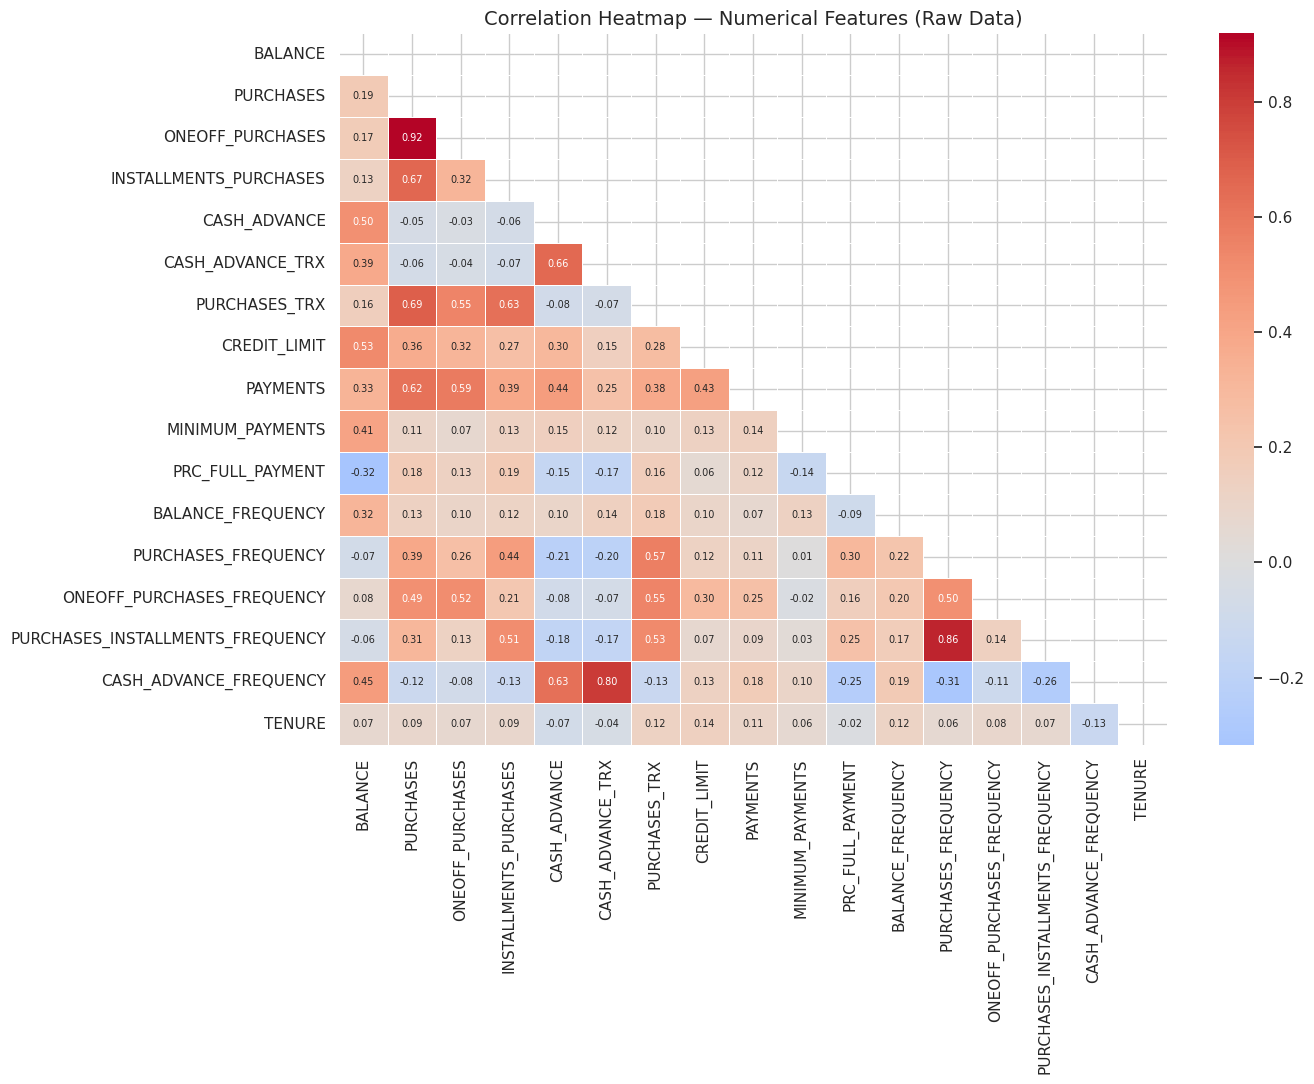

In [12]:
# Convert possible numeric-looking text columns to numeric
df_numeric_ready = df.copy()

for col in df_numeric_ready.columns:
    if col != "CUST_ID":
        df_numeric_ready[col] = (
            df_numeric_ready[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .str.strip()
        )
        df_numeric_ready[col] = pd.to_numeric(df_numeric_ready[col], errors="coerce")

# Keep numeric columns only
numeric_df = df_numeric_ready.select_dtypes(include="number")

# Drop CUST_ID if it accidentally stayed numeric
numeric_df = numeric_df.drop(columns=["CUST_ID"], errors="ignore")

# Drop columns that are completely NaN
numeric_df = numeric_df.dropna(axis=1, how="all")

# Drop constant columns, because correlation is undefined for them
numeric_df = numeric_df.loc[:, numeric_df.nunique(dropna=True) > 1]


corr_matrix = numeric_df.corr()

if corr_matrix.empty or corr_matrix.isna().all().all():
    print("Correlation heatmap cannot be created because the correlation matrix is empty or all NaN.")
else:
    fig, ax = plt.subplots(figsize=(14, 11))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.4,
        ax=ax,
        annot_kws={"size": 7}
    )

    ax.set_title("Correlation Heatmap — Numerical Features (Raw Data)", fontsize=14)
    plt.tight_layout()
    plt.show()

### 10 · Initial Observations

Based on the EDA above, the following key findings shape the preprocessing decisions:

| Observation | Finding | Pipeline Action |
|---|---|---|
| **Missing values** | `MINIMUM_PAYMENTS` and occasionally `CREDIT_LIMIT` have missing entries | Median imputation (robust to outliers) |
| **Duplicate rows** | A small number of exact duplicate records may be present | Drop duplicates before any transformation |
| **Invalid −1 values** | Some cells use −1 as a placeholder for unknown/invalid data | Remove affected rows entirely |
| **Right-skewed distributions** | All amount-based columns show heavy right skew; mean >> median | Log-transform with `np.log1p()` |
| **Extreme outliers** | Boxplots show long upper whiskers, especially for `CASH_ADVANCE` and `PURCHASES` | Log transformation compresses the tail |
| **Frequency columns** | Values should lie in `[0, 1]`; some may exceed 1 due to data errors | Cap at 1 |
| **Strong correlations** | `PURCHASES` correlates with `PURCHASES_TRX` and `ONEOFF_PURCHASES` | Feature engineering extracts higher-level KPIs; PCA absorbs residual collinearity |
| **`CUST_ID` column** | This is a categorical identifier with no behavioral signal | Drop before clustering |

---

---
## Data Preprocessing Pipeline

The pipeline proceeds through **5 steps**. We work on a fresh copy of the raw dataframe so the EDA section above remains unaffected.

---
## Step 1 · Initial Data Cleaning & Integrity

Before we can trust any summary statistic or train any model, the data must be structurally clean:
- **Duplicate rows** are removed to ensure each customer appears only once.
- **Rows containing −1** are removed because these are invalid placeholders, not real behavioral data.
- **`CUST_ID`** is dropped because it is a string identifier that carries no distance-meaningful information and would need to be one-hot encoded (adding noise) or ignored. Removing it avoids any accidental influence on K-Means centroids.

In [14]:
# ── Work on a clean copy separate from EDA ────────────────────────────────────
# Use the already correctly parsed DataFrame, not the raw CSV structure.
df_clean = df.copy()

print(f"Shape before cleaning : {df_clean.shape}")

# 1a. Remove duplicate rows
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"  Duplicate rows removed : {n_before - len(df_clean)}")

# 1b. Remove rows that contain -1 in any numeric column
#     (-1 is not a valid value for any behavioral variable in this dataset)
numeric_cols = df_clean.select_dtypes(include="number").columns
invalid_mask = (df_clean[numeric_cols] == -1).any(axis=1)
n_before = len(df_clean)
df_clean = df_clean[~invalid_mask].copy()
print(f"  Rows with -1 removed   : {n_before - len(df_clean)}")

# 1c. Drop the customer ID — it is an identifier, not a behavioral feature
if "CUST_ID" in df_clean.columns:
    df_clean = df_clean.drop(columns=["CUST_ID"])
    print("  CUST_ID column dropped.")

print(f"Shape after cleaning  : {df_clean.shape}")
display(df_clean.head())


Shape before cleaning : (9845, 18)
  Duplicate rows removed : 895
  Rows with -1 removed   : 10
  CUST_ID column dropped.
Shape after cleaning  : (8940, 17)


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,BALANCE_FREQUENCY,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,TENURE
17,27.6259,234.4800,0.0000,234.4800,0.0000,0.0000,12.0000,"2,500.0000",109.2811,93.6246,0.0000,0.8182,1.0000,0.0000,1.0000,0.0000,12.0000
18,"8,791.1611",0.0000,0.0000,0.0000,"3,706.7551",4.0000,0.0000,"12,000.0000","2,244.6276","2,916.2789",0.0000,1.0000,0.0000,0.0000,0.0000,0.3333,12.0000
19,165.8081,981.1900,823.3900,157.8000,0.0000,0.0000,16.0000,"9,000.0000",672.4469,105.3507,0.2500,0.7143,0.7143,0.5714,0.2857,0.0000,7.0000
20,"4,157.9339",929.2000,631.4000,297.8000,"2,592.2380",8.0000,12.0000,"8,000.0000",934.6344,"1,076.5399",0.0000,1.0000,0.5833,0.3333,0.2500,0.5833,12.0000
21,19.9457,170.0000,170.0000,0.0000,0.0000,0.0000,1.0000,"6,500.0000",734.6130,166.0576,1.0000,0.2727,0.0833,0.0833,0.0000,0.0000,12.0000


---
## Step 2 · Imputation & Distribution Transformation

### 2a · Median Imputation

After removal of duplicates and invalid rows, some `NaN` values may still remain (e.g., in `MINIMUM_PAYMENTS`). We replace them with the **column median** rather than the mean because:
- These distributions are heavily right-skewed (as confirmed in EDA).
- The **mean** is pulled far above the typical customer value by outliers.
- The **median** is a more representative central value for the majority of customers

In [15]:
# Make a numeric-only copy for clustering preprocessing
df_model = df_clean.copy()

# Drop identifier column if it exists
df_model = df_model.drop(columns=["CUST_ID"], errors="ignore")

# Convert all remaining columns to numeric
for col in df_model.columns:
    df_model[col] = (
        df_model[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Drop columns that are completely NaN after conversion
df_model = df_model.dropna(axis=1, how="all")

print(f"Shape before imputation: {df_model.shape}")
print("Total NaN before imputation:", df_model.isna().sum().sum())

Shape before imputation: (8940, 17)
Total NaN before imputation: 413


In [16]:
# 2a. Median imputation for all remaining NaN values
imputer = SimpleImputer(strategy="median")

df_imputed = pd.DataFrame(
    imputer.fit_transform(df_model),
    columns=df_model.columns
)

print("Remaining NaN after imputation:", df_imputed.isnull().sum().sum())

Remaining NaN after imputation: 0


### 2b · Log Transformation (`np.log1p`)

K-Means uses Euclidean distance, which is highly sensitive to scale and skew. A customer who spent €10,000 in one purchase will dominate the distance calculations and attract a centroid on their own, regardless of their other characteristics. `np.log1p(x) = log(1 + x)` compresses extreme values while:
- Handling **zeros safely** (log(0) is undefined, but log(1+0) = 0).
- Making distributions more **symmetric** and closer to Gaussian.
- Preserving the **rank order** of all values.

In [17]:
# Normalize column names
df_imputed.columns = (
    df_imputed.columns
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace(" ", "_")
)


# 2b. Log-transform the heavily right-skewed amount-based columns
log_cols = [
    "BALANCE",
    "PURCHASES",
    "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE",
    "PAYMENTS",
    "MINIMUM_PAYMENTS"
]

# Apply transformation only to columns that exist in the dataset
log_cols = [c for c in log_cols if c in df_imputed.columns]

print(f"Log-transformed columns ({len(log_cols)}): {log_cols}")

if len(log_cols) > 0:
    df_imputed[log_cols] = df_imputed[log_cols].apply(np.log1p)

    display(
        df_imputed[log_cols]
        .describe()
        .T[["mean", "std", "min", "50%", "max"]]
    )
else:
    print("No matching amount-based columns found. Check column names above.")

Log-transformed columns (7): ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PAYMENTS', 'MINIMUM_PAYMENTS']


,mean,std,min,50%,max
BALANCE,6.1607,2.0129,0.0000,6.7717,9.8545
PURCHASES,4.8992,2.9161,0.0000,5.8917,10.8004
ONEOFF_PURCHASES,3.2036,3.2446,0.0000,3.6636,10.6155
INSTALLMENTS_PURCHASES,3.3504,3.0824,0.0000,4.4956,10.0213
CASH_ADVANCE,3.3206,3.5665,0.0000,0.0000,10.7608
PAYMENTS,6.6243,1.5921,0.0000,6.7535,10.8341
MINIMUM_PAYMENTS,5.9154,1.1697,0.0190,5.7465,11.2438


Let's verify the transformation improved the distributions by comparing skewness before and after:

In [18]:
# Before skewness: cleaned but not yet log-transformed data
# After skewness: imputed data after log1p transformation
available_log_cols = [c for c in log_cols if c in df_clean.columns and c in df_imputed.columns]

if len(available_log_cols) == 0:
    print("No log-transformed columns available for skewness comparison.")
else:
    before_skew = df_clean[available_log_cols].dropna().skew()
    after_skew = df_imputed[available_log_cols].skew()

    skew_comparison = pd.DataFrame({
        "Skewness Before log1p": before_skew,
        "Skewness After log1p": after_skew
    }).round(3)

    print("Skewness comparison (closer to 0 = more symmetric):")
    display(skew_comparison)
    print("Skweness Interpretation:\nSkewness = 0: The distribution is symmetric means the mean, median and mode are equal.\nSkewness > 0: The distribution is positively skewed (right-skewed) with the tail on the right side longer than the left.\nSkewness < 0: The distribution is negatively skewed (left-skewed) with the tail on the left side longer than the right.")
    print("\nAs we can see, we went from positive to slighty negative skewness, but we got much closer 0 and that is what we wanted.")

Skewness comparison (closer to 0 = more symmetric):


,Skewness Before log1p,Skewness After log1p
BALANCE,2.3820,-0.8620
PURCHASES,8.0520,-0.7650
ONEOFF_PURCHASES,9.9330,0.1860
INSTALLMENTS_PURCHASES,7.2180,-0.0240
CASH_ADVANCE,5.1440,0.2620
PAYMENTS,5.8660,-1.7790
MINIMUM_PAYMENTS,13.5920,0.2700


Skweness Interpretation:
Skewness = 0: The distribution is symmetric means the mean, median and mode are equal.
Skewness > 0: The distribution is positively skewed (right-skewed) with the tail on the right side longer than the left.
Skewness < 0: The distribution is negatively skewed (left-skewed) with the tail on the left side longer than the right.

As we can see, we went from positive to slighty negative skewness, but we got much closer 0 and that is what we wanted.


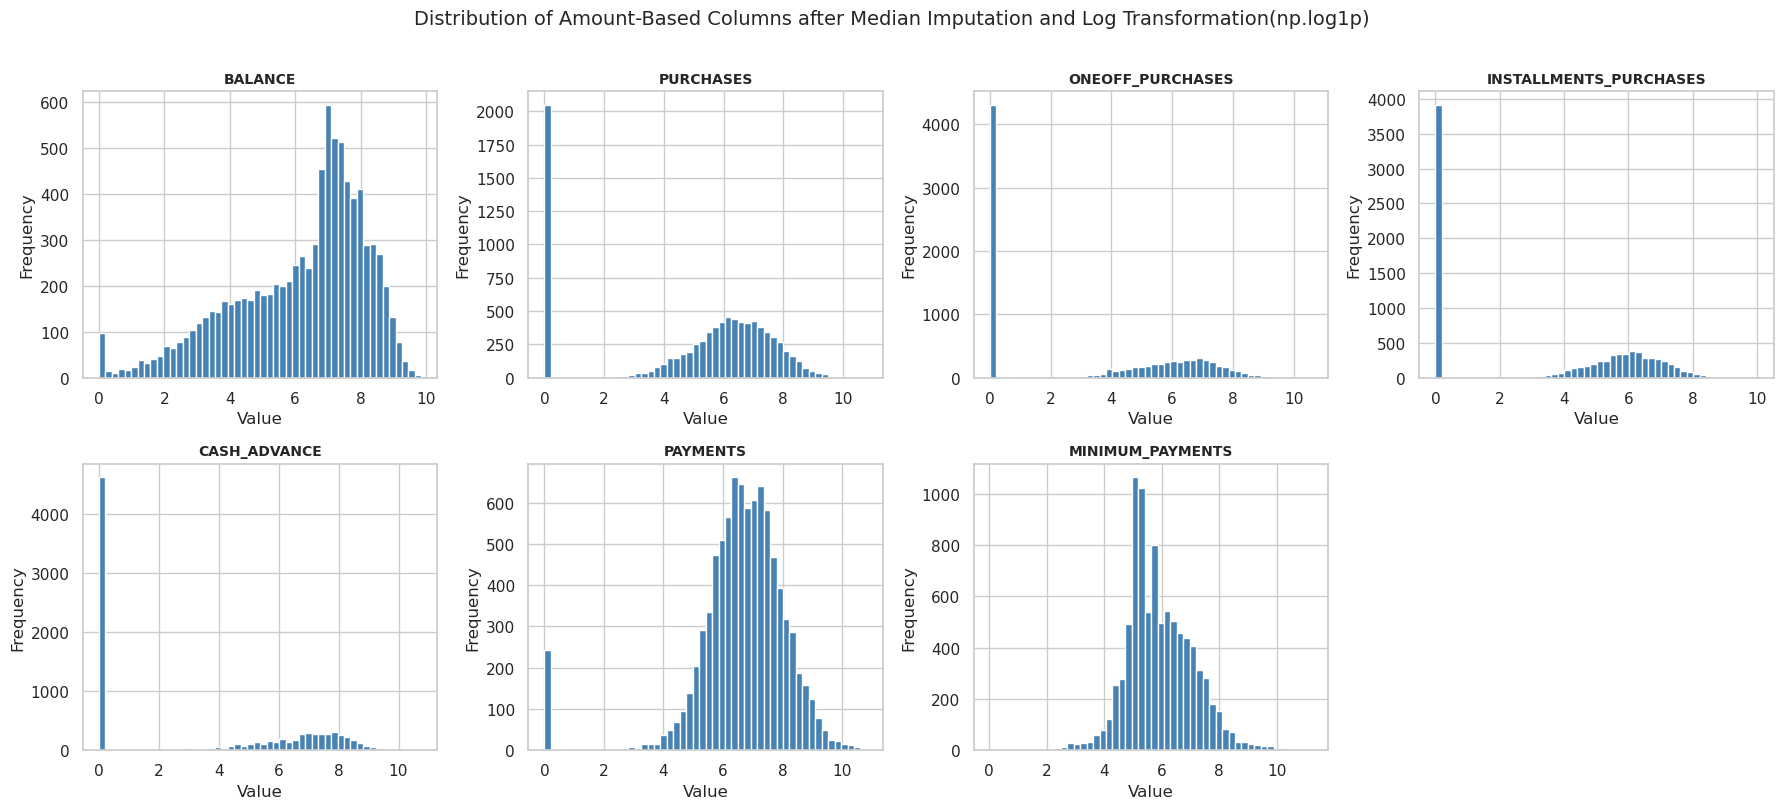

In [19]:
cols = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES',
               'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
               'PAYMENTS', 'MINIMUM_PAYMENTS']

# Keep only columns that exist in this particular file
cols = [c for c in cols if c in df_imputed.columns]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(df_imputed[col].dropna(), bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide any unused subplot panels
for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of Amount-Based Columns after Median Imputation and Log Transformation(np.log1p)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Step 3 · Frequency Column Normalisation

### 3a · Value Capping

All frequency columns are designed to express a score in `[0, 1]`. Any value above 1 is a data quality artifact. We cap them at 1 rather than removing the rows, because the customer's other data is still valid and informative.


In [20]:
# Identify all frequency columns (case-insensitive search)
freq_cols = [c for c in df_imputed.columns if "FREQUENCY" in c.upper()]

if len(freq_cols) == 0:
    print("No frequency columns found; skipping capping.")
else:
    # 3a. Cap any value above 1 to 1 to enforce the 0-1 scale
    df_imputed[freq_cols] = df_imputed[freq_cols].clip(upper=1.0)
    print(f"  Max after capping: {df_imputed[freq_cols].max().max():.4f} (should be ≤ 1)")


  Max after capping: 1.0000 (should be ≤ 1)


---
## Step 4 · Behavioral Feature Engineering

Raw columns measure absolute amounts, but K-Means needs features that **capture behavioral patterns** rather than just total spend. Three interpretable KPIs are engineered:

| KPI | Formula | Behavioral Meaning |
|---|---|---|
| `MONTHLY_AVG_SPENDING` | `PURCHASES / TENURE` | How much does this customer spend per month on average? |
| `CREDIT_UTILIZATION` | `BALANCE / CREDIT_LIMIT` | How close to their credit limit does the customer live? (0 = unused, 1 = maxed out) |
| `PAYMENT_RATIO` | `PAYMENTS / MINIMUM_PAYMENTS` | How disciplined is the customer's repayment behaviour? (1 = pays exactly minimum, higher = pays more) |

> **Division-by-zero handling:** `TENURE = 0` and `MINIMUM_PAYMENTS = 0` would cause infinite values. We replace these with `0` using `replace([inf, -inf], 0)`, which is the appropriate behavioral interpretation (no activity → no average spending; no minimum payment due → payment ratio is effectively 0).

In [21]:
df_feat = df_imputed.copy()

# ── New KPIs ──────────────────────────────────────────────────────────────────
required_cols = [
    "PURCHASES",
    "TENURE",
    "BALANCE",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "MINIMUM_PAYMENTS"
]
missing_cols = [c for c in required_cols if c not in df_feat.columns]

if missing_cols:
    raise KeyError(f"Cannot create KPI features. Missing columns: {missing_cols}")

# Avoid division by zero by temporarily replacing zero denominators with NaN.
tenure_safe = df_feat["TENURE"].replace(0, np.nan)
credit_limit_safe = df_feat["CREDIT_LIMIT"].replace(0, np.nan)
minimum_payments_safe = df_feat["MINIMUM_PAYMENTS"].replace(0, np.nan)

# Average monthly spending (uses log-transformed PURCHASES — relative measure)
df_feat["MONTHLY_AVG_SPENDING"] = df_feat["PURCHASES"] / tenure_safe

# Credit utilisation ratio: balance relative to the credit limit
df_feat["CREDIT_UTILIZATION"] = df_feat["BALANCE"] / credit_limit_safe

# Payment discipline: how much the customer pays vs the minimum required
df_feat["PAYMENT_RATIO"] = df_feat["PAYMENTS"] / minimum_payments_safe

# Replace possible inf/NaN values created by division
new_kpi_cols = ["MONTHLY_AVG_SPENDING", "CREDIT_UTILIZATION", "PAYMENT_RATIO"]
df_feat[new_kpi_cols] = (
    df_feat[new_kpi_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("New features added: MONTHLY_AVG_SPENDING, CREDIT_UTILIZATION, PAYMENT_RATIO")
print(f"Dataset shape after feature engineering: {df_feat.shape}")

# Quick sanity check — should be no inf values
inf_check = np.isinf(df_feat.select_dtypes("number")).sum().sum()
print(f"Infinite values remaining: {inf_check}  (should be 0)")

display(df_feat[new_kpi_cols].describe().T)


New features added: MONTHLY_AVG_SPENDING, CREDIT_UTILIZATION, PAYMENT_RATIO
Dataset shape after feature engineering: (8940, 20)
Infinite values remaining: 0  (should be 0)


,count,mean,std,min,25%,50%,75%,max
MONTHLY_AVG_SPENDING,"8,940.0000",0.4299,0.2653,0.0000,0.3156,0.5058,0.6065,1.5086
CREDIT_UTILIZATION,"8,940.0000",0.0024,0.0026,0.0000,0.0009,0.0017,0.0034,0.1336
PAYMENT_RATIO,"8,940.0000",1.2165,3.1311,0.0000,0.9861,1.1266,1.3271,244.6005


---
## Step 5 · Final Scaling & Dimensionality Reduction

### 5a · Standard Scaling

Even after log transformation, the features still live on very different scales:
- Frequency columns: `[0, 1]`
- Log-transformed amounts: `[0, ~10]`
- Transaction counts: `[0, ~100]`
- Engineered ratios: `[0, ~50+]`

`StandardScaler` transforms each feature to have **mean = 0** and **standard deviation = 1**. This ensures that K-Means distances are not dominated by high-magnitude features and that each variable contributes equally to cluster assignments.

In [22]:
# 5a. Standard scaling — K-Means needs features on comparable scales
# Keep only numeric columns and make sure no NaN/inf values remain.
X_features = df_feat.select_dtypes(include="number").copy()
X_features = X_features.replace([np.inf, -np.inf], np.nan)
X_features = X_features.fillna(X_features.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

print(f"Scaled array shape         : {X_scaled.shape}")
print(f"Mean of scaled features    : {X_scaled.mean(axis=0).round(6).tolist()}")   # Should all be ~0
print(f"Std dev of scaled features : {X_scaled.std(axis=0).round(6).tolist()}")    # Should all be ~1


Scaled array shape         : (8940, 20)
Mean of scaled features    : [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0, -0.0, 0.0, 0.0, -0.0, 0.0, -0.0, 0.0, -0.0, -0.0, 0.0, -0.0, 0.0]
Std dev of scaled features : [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


### 5b · Principal Component Analysis (PCA)

After scaling we may still have 20+ correlated features. PCA rotates the feature space into a new set of orthogonal (uncorrelated) axes called **principal components**, ordered by the amount of variance they explain. Benefits:
- **Reduces dimensionality** → faster K-Means convergence.
- **Eliminates residual multicollinearity** → more stable cluster boundaries.
- **Reduces noise** from low-variance directions.

We configure PCA to retain enough components to explain **90% of total variance** — a standard threshold that preserves most of the information while removing noise.

Components needed to explain 90% variance: 10
Cumulative variance (first 10 components):
  PC1: 0.2908  ()
  PC2: 0.4778  ()
  PC3: 0.5618  ()
  PC4: 0.6359  ()
  PC5: 0.7020  ()
  PC6: 0.7544  ()
  PC7: 0.8012  ()
  PC8: 0.8409  ()
  PC9: 0.8719  ()
  PC10: 0.9004  (✓ 90% reached)


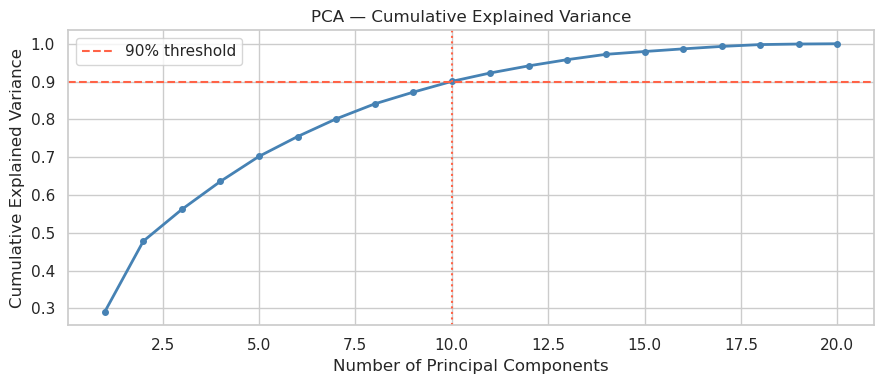

In [23]:
# 5b-i. First run PCA with all components to see the explained variance curve
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90     = np.argmax(cumulative_variance >= 0.90) + 1

print(f'Components needed to explain 90% variance: {n_components_90}')
print(f'Cumulative variance (first 10 components):')
for i, v in enumerate(cumulative_variance[:10], 1):
    print(f'  PC{i}: {v:.4f}  ({"✓ 90% reached" if i == n_components_90 else ""})')

# Plot the explained variance curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
        marker='o', markersize=4, color='steelblue', linewidth=2)
ax.axhline(0.90, color='tomato', linestyle='--', label='90% threshold')
ax.axvline(n_components_90, color='tomato', linestyle=':')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA — Cumulative Explained Variance')
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
# 5b-ii. Re-run PCA keeping enough components for 90% variance.
# The component count must not exceed min(n_samples, n_features).
max_components = min(X_scaled.shape[0], X_scaled.shape[1])
n_final = max(2, min(10, n_components_90, max_components))
print(f"Final number of PCA components: {n_final}")

pca = PCA(n_components=n_final, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Wrap result in a labelled DataFrame
pca_columns = [f"PC{i+1}" for i in range(n_final)]
df_pca = pd.DataFrame(X_pca, columns=pca_columns)

print("\nExplained variance per component:")
for col, var in zip(pca_columns, pca.explained_variance_ratio_):
    print(f"  {col}: {var:.4f}  ({var*100:.2f}%)")
print(
    f"  Total variance retained: {pca.explained_variance_ratio_.sum():.4f} "
    f"({pca.explained_variance_ratio_.sum()*100:.2f}%)"
)


Final number of PCA components: 10

Explained variance per component:
  PC1: 0.2908  (29.08%)
  PC2: 0.1870  (18.70%)
  PC3: 0.0840  (8.40%)
  PC4: 0.0741  (7.41%)
  PC5: 0.0661  (6.61%)
  PC6: 0.0524  (5.24%)
  PC7: 0.0468  (4.68%)
  PC8: 0.0397  (3.97%)
  PC9: 0.0310  (3.10%)
  PC10: 0.0285  (2.85%)
  Total variance retained: 0.9004 (90.04%)


---
## Final Output

The fully prepared dataset is now ready for K-Means clustering. Let's confirm its shape and preview the first few rows.

In [25]:
print('═' * 55)
print('  PREPARED DATASET — READY FOR K-MEANS CLUSTERING')
print('═' * 55)
print(f'  Final shape : {df_pca.shape[0]:,} rows × {df_pca.shape[1]} principal components')
print(f'  Variance retained : {pca.explained_variance_ratio_.sum()*100:.1f}%')
print('═' * 55)
print()
print('Preview of PCA components (first 5 rows):')
display(df_pca.head())

print('\nColumn statistics:')
display(df_pca.describe().round(4))

═══════════════════════════════════════════════════════
  PREPARED DATASET — READY FOR K-MEANS CLUSTERING
═══════════════════════════════════════════════════════
  Final shape : 8,940 rows × 10 principal components
  Variance retained : 90.0%
═══════════════════════════════════════════════════════

Preview of PCA components (first 5 rows):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,1.3072,-2.3546,1.3052,-0.9672,0.3817,-0.6355,-0.8147,0.6592,0.2213,0.8474
1,-3.4342,2.4191,-0.6951,-0.7293,1.8211,-0.5194,-0.2022,-1.2457,0.2178,-0.2065
2,2.5097,-0.8704,-1.7943,0.1228,-2.7082,-0.9937,-0.4557,-2.2120,-0.1534,-0.4499
3,0.0358,2.9959,-0.4263,-0.4858,-0.7415,-0.4593,-0.5253,0.6430,-0.6220,0.4582
4,0.0406,-2.7311,-2.9868,-0.8300,0.3295,0.2647,1.5131,0.1087,-0.5997,-0.8508



Column statistics:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
count,"8,940.0000","8,940.0000","8,940.0000","8,940.0000","8,940.0000","8,940.0000","8,940.0000","8,940.0000","8,940.0000","8,940.0000"
mean,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000
std,2.4117,1.9341,1.2965,1.2171,1.1500,1.0240,0.9672,0.8911,0.7873,0.7549
min,-7.8960,-8.8225,-7.5068,-13.0950,-9.5974,-3.8029,-47.0750,-9.5123,-2.5632,-14.2970
25%,-1.9307,-1.2604,-0.8333,-0.8050,-0.3443,-0.3714,-0.4801,-0.4287,-0.5092,-0.3863
50%,0.3415,0.0061,0.0110,0.0047,0.2611,0.0062,-0.0927,0.0222,-0.0869,0.0553
75%,1.7643,1.2004,0.7970,0.7753,0.6706,0.3897,0.3527,0.4518,0.4079,0.4151
max,9.3619,10.9198,22.3133,19.1916,2.6765,57.6645,11.5542,7.2840,8.8012,3.7849


In [26]:
# Optional: save the prepared dataset to disk for use in the clustering notebook
df_pca.to_csv('credit_card_pca_ready.csv', index=False)
print('PCA-prepared dataset saved to: credit_card_pca_ready.csv')

PCA-prepared dataset saved to: credit_card_pca_ready.csv


---
## Pipeline Summary

| Step | Action | Rationale |
|---|---|---|
| **EDA** | Shape, types, missing values, duplicates, −1 check, statistics, distributions, boxplots, frequency ranges, correlations | Understand the raw data before touching it |
| **Step 1** | Drop duplicates, remove −1 rows, drop `CUST_ID` | Remove noise and identifiers that distort Euclidean distance |
| **Step 2** | Median imputation and `log1p` on amount columns | Robust missing-value fill + compress heavy right skew |
| **Step 3** | Cap frequency columns at 1 | Enforce intended `[0,1]` scale  |
| **Step 4** | Engineer `MONTHLY_AVG_SPENDING`, `CREDIT_UTILIZATION`, `PAYMENT_RATIO` | Capture higher-level behavioral signals |
| **Step 5** | `StandardScaler` → `PCA` (90% variance retained) | Equal feature weight + remove collinearity + reduce dimensionality |

The output `df_pca` is a clean, scaled, and dimensionality-reduced matrix ready to be passed directly into clustering models.

## 2.3 Model Selection

This section introduces the clustering models that will be trained, compared, and evaluated on the preprocessed credit card dataset.

The dataset is **unlabeled** — there is no target variable indicating which group a customer belongs to. The goal is **customer segmentation**: discovering natural groups of similar customers based on their behavioral patterns. Clustering is the appropriate family of methods, as it discovers structure in the data without requiring ground truth.

We chose the following three approaches:

1. **Random Cluster Assignment (Naive Baseline)** — assigns customers to clusters randomly, without using any information from the data. Serves as a lower bound for performance.
2. **K-Means Clustering** — a simple, computationally efficient, and widely used algorithm. Partitions data into *k* groups by minimizing within-cluster variance.
3. **Gaussian Mixture Model (GMM)** — a probabilistic model representing each cluster as a Gaussian distribution. Provides soft (probabilistic) cluster assignments, making it more flexible than K-Means.

All models are evaluated using: Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Score. GMM additionally uses AIC and BIC.

**All models are trained on the same preprocessed PCA-transformed dataset** to ensure a fair comparison.

## 2.4 Explanation of the Models

### K-Means Clustering

Clustering is the task of grouping observations into subsets — clusters — such that points within a cluster are more similar to each other than to points in other clusters. K-Means is one of the most widely used clustering algorithms. It partitions data into exactly *k* groups, each represented by a **centroid** — the mean position of all assigned points. The algorithm proceeds iteratively: in the assignment step, each point is assigned to the nearest centroid (Euclidean distance); in the update step, each centroid is recomputed as the mean of its assigned points. These steps alternate until assignments no longer change or a maximum iteration count is reached.

The objective is to **minimize inertia** — the total sum of squared distances between each data point and its assigned centroid. Because the algorithm is sensitive to initial centroid placement, multiple restarts with different random initializations (`n_init`) are used and the run with the lowest inertia is kept. The result of training is a set of *k* centroids and a hard cluster label for every customer.

---

### Gaussian Mixture Model

A Gaussian Mixture Model (GMM) is a **probabilistic generative model** that assumes the observed data are drawn from a mixture of several Gaussian (normal) distributions. Each Gaussian component represents one cluster, characterized by its mean vector and covariance matrix. Unlike K-Means, which makes hard cluster assignments, GMM produces **soft assignments**: each customer receives a probability of belonging to each cluster, and the final label is the component with the highest probability.

The model is estimated using the **Expectation-Maximization (EM) algorithm**, which alternates between computing the probability that each point belongs to each component (E-step) and updating the component parameters to maximize data likelihood (M-step). The covariance type `"full"` allows each component to have its own arbitrary covariance matrix, giving maximum flexibility to fit non-spherical cluster shapes. The number of components is selected using both clustering quality metrics and information criteria (AIC and BIC).

## 2.5 Prepare Modeling Dataset

We select the input matrix for all clustering models. Priority is given to `df_pca` produced in the preprocessing pipeline. A copy of the original cleaned customer-level data is also preserved for cluster profiling and export.

In [27]:
X_model = globals()["df_pca"].copy()
# Ensure only numeric columns are used
X_model = X_model.select_dtypes(include="number").copy()

print(f"\nX_model shape: {X_model.shape}")
print(f"Missing values: {X_model.isnull().sum().sum()}")
print("\nFirst few rows:")
display(X_model.head())


# ── Preserve original customer-level data for profiling ───────────────────
# Use df_feat (feature-engineered, before PCA) if available, else df_clean or df
df_profile = None
profile_source = None

for candidate_name in ["df_feat", "df_clean", "cards", "df"]:
    if candidate_name in globals():
        candidate = globals()[candidate_name]

        if isinstance(candidate, pd.DataFrame):
            df_profile = candidate.copy()
            profile_source = candidate_name
            print(
                f"\nUsing '{candidate_name}' as profiling base "
                f"(shape: {df_profile.shape})."
            )
            break

if df_profile is None:
    df_profile = X_model.copy()
    profile_source = "X_model"
    print("\nNo raw DataFrame found; profiling will use X_model directly.")


# ── Align profiling dataset with X_model length ────────────────────────────
if len(df_profile) != len(X_model):
    print(
        f"\nWarning: df_profile has {len(df_profile)} rows, "
        f"but X_model has {len(X_model)} rows."
    )
    print("Profiling dataset will be aligned to the first rows of X_model length.")

    df_profile = df_profile.reset_index(drop=True).iloc[:len(X_model)].copy()
else:
    df_profile = df_profile.reset_index(drop=True)


# ── Keep CUST_ID separately if available ───────────────────────────────────
cust_ids = None
cust_id_col = None

if "df" in globals() and isinstance(df, pd.DataFrame) and "CUST_ID" in df.columns:
    cust_ids = df["CUST_ID"].reset_index(drop=True).iloc[:len(X_model)]
    cust_id_col = "CUST_ID"
    print(f"CUST_ID preserved from df for export ({len(cust_ids)} values).")

elif "cards" in globals() and isinstance(cards, pd.DataFrame) and "CUST_ID" in cards.columns:
    cust_ids = cards["CUST_ID"].reset_index(drop=True).iloc[:len(X_model)]
    cust_id_col = "CUST_ID"
    print(f"CUST_ID preserved from cards for export ({len(cust_ids)} values).")

elif "df_profile" in globals() and isinstance(df_profile, pd.DataFrame) and "CUST_ID" in df_profile.columns:
    cust_ids = df_profile["CUST_ID"].reset_index(drop=True).iloc[:len(X_model)]
    cust_id_col = "CUST_ID"
    print(f"CUST_ID preserved from df_profile for export ({len(cust_ids)} values).")

else:
    print("CUST_ID not available.")


X_model shape: (8940, 10)
Missing values: 0

First few rows:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,1.3072,-2.3546,1.3052,-0.9672,0.3817,-0.6355,-0.8147,0.6592,0.2213,0.8474
1,-3.4342,2.4191,-0.6951,-0.7293,1.8211,-0.5194,-0.2022,-1.2457,0.2178,-0.2065
2,2.5097,-0.8704,-1.7943,0.1228,-2.7082,-0.9937,-0.4557,-2.2120,-0.1534,-0.4499
3,0.0358,2.9959,-0.4263,-0.4858,-0.7415,-0.4593,-0.5253,0.6430,-0.6220,0.4582
4,0.0406,-2.7311,-2.9868,-0.8300,0.3295,0.2647,1.5131,0.1087,-0.5997,-0.8508



Using 'df_feat' as profiling base (shape: (8940, 20)).
CUST_ID preserved from df for export (8940 values).


## 2.6a K-Means Training and Hyperparameter Tuning

K-Means is evaluated for *k* values from 2 to 10 using the already prepared model-ready dataset from the preprocessing/PCA section. No preprocessing, scaling, feature engineering, or PCA is recomputed here.

For each value of *k*, we calculate:

- **Inertia** — lower is better, but it naturally decreases as *k* increases, so it is mainly used for the elbow method.
- **Silhouette Score** — higher is better.
- **Davies-Bouldin Index** — lower is better.
- **Calinski-Harabasz Score** — higher is better.

A key distinction is made between:

- `metric_best_k`: the value suggested by internal validation metrics,
- `final_selected_k`: the value selected for the final customer segmentation.

Although k = 2 may achieve the strongest internal validation metrics, it produces only two very broad customer groups. Since the goal of this project is customer segmentation, the final solution should also be practically interpretable and useful. Therefore, we inspect k = 3, k = 4, and k = 5 and select the number of clusters that provides the best balance between metric quality and business interpretability.

In [29]:
# Evaluation range requested in the assignment
k_range = range(2, 11)
candidate_k_values = [3, 4, 5]


def compute_cluster_metrics(X, labels):
    """Compute common internal clustering metrics."""
    return {
        "Silhouette Score": silhouette_score(X, labels),
        "Davies-Bouldin Index": davies_bouldin_score(X, labels),
        "Calinski-Harabasz Score": calinski_harabasz_score(X, labels),
    }


def cluster_size_stats(labels):
    """Return basic cluster size diagnostics."""
    counts = pd.Series(labels).value_counts().sort_index()
    pct = counts / counts.sum()
    return {
        "Min Cluster Size": int(counts.min()),
        "Max Cluster Size": int(counts.max()),
        "Min Cluster %": float(pct.min()),
        "Max Cluster %": float(pct.max()),
    }


def profile_separation_score(profile_df, labels):
    """
    Approximate how different cluster profiles are on original/profile variables.
    Higher values indicate stronger separation between cluster mean profiles.
    """
    numeric_profile = profile_df.select_dtypes(include="number").copy()
    numeric_profile = numeric_profile.replace([np.inf, -np.inf], np.nan)
    numeric_profile = numeric_profile.fillna(numeric_profile.median(numeric_only=True))

    # Remove identifiers from profile scoring if present.
    id_like_cols = [c for c in numeric_profile.columns if c.upper() in {"CUST_ID", "CUSTOMER_ID", "ID"}]
    numeric_profile = numeric_profile.drop(columns=id_like_cols, errors="ignore")

    if numeric_profile.shape[1] == 0:
        return np.nan

    standardized = (numeric_profile - numeric_profile.mean()) / numeric_profile.std(ddof=0).replace(0, np.nan)
    standardized = standardized.fillna(0)
    profile_means = standardized.assign(Cluster=labels).groupby("Cluster").mean()

    # Mean absolute distance of each cluster profile from the overall average profile.
    return float(profile_means.abs().mean(axis=1).mean())


def metric_best_from_results(results_df):
    """
    Select metric-best k by majority vote across Silhouette, Davies-Bouldin,
    and Calinski-Harabasz. If there is no majority, prefer Silhouette.
    """
    best_sil = int(results_df["Silhouette Score"].idxmax())
    best_db = int(results_df["Davies-Bouldin Index"].idxmin())
    best_ch = int(results_df["Calinski-Harabasz Score"].idxmax())

    votes = [best_sil, best_db, best_ch]
    vote_counts = Counter(votes)
    most_common_k, most_common_count = vote_counts.most_common(1)[0]

    if most_common_count >= 2:
        metric_best = int(most_common_k)
    else:
        metric_best = best_sil

    return metric_best, {
        "Best by Silhouette": best_sil,
        "Best by Davies-Bouldin": best_db,
        "Best by Calinski-Harabasz": best_ch,
    }


def build_candidate_table(results_df, labels_by_k, profile_df, candidates=candidate_k_values):
    """Build an interpretability-focused diagnostics table for candidate k values."""
    rows = []
    for k in candidates:
        labels = labels_by_k[k]
        row = {"k": k}
        row.update(results_df.loc[k].to_dict())
        row.update(cluster_size_stats(labels))
        row["Profile Separation Score"] = profile_separation_score(profile_df, labels)
        rows.append(row)
    return pd.DataFrame(rows).set_index("k")


def select_interpretable_k(results_df, candidate_table, metric_best_k, prefer_k=4):
    """
    Select a final k based on interpretability and business usefulness.
    The logic prefers k=4 when it has reasonable cluster sizes and competitive metrics.
    """
    # Avoid tiny segments unless there is no better alternative.
    viable = candidate_table[candidate_table["Min Cluster %"] >= 0.03].copy()
    if viable.empty:
        viable = candidate_table.copy()

    # Rank candidates by a balanced score: good Silhouette, low DB, good CH,
    # meaningful profile separation, and no extremely dominant cluster.
    score_input = viable[[
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Score",
        "Profile Separation Score",
        "Max Cluster %",
    ]].copy()

    normalized = pd.DataFrame(index=score_input.index)
    for col in ["Silhouette Score", "Calinski-Harabasz Score", "Profile Separation Score"]:
        span = score_input[col].max() - score_input[col].min()
        normalized[col] = 1.0 if span == 0 else (score_input[col] - score_input[col].min()) / span

    for col in ["Davies-Bouldin Index", "Max Cluster %"]:
        span = score_input[col].max() - score_input[col].min()
        normalized[col] = 1.0 if span == 0 else (score_input[col].max() - score_input[col]) / span

    viable["Interpretability Score"] = (
        0.30 * normalized["Profile Separation Score"] +
        0.25 * normalized["Silhouette Score"] +
        0.20 * normalized["Davies-Bouldin Index"] +
        0.15 * normalized["Calinski-Harabasz Score"] +
        0.10 * normalized["Max Cluster %"]
    )

    # Prefer k=4 if it is viable and not clearly worse than the best candidate.
    best_score = viable["Interpretability Score"].max()
    if prefer_k in viable.index and viable.loc[prefer_k, "Interpretability Score"] >= best_score - 0.15:
        final_k = prefer_k
        reason = "k=4 is viable and provides a practical balance between detail and interpretability."
    else:
        final_k = int(viable["Interpretability Score"].idxmax())
        reason = "selected because it has the best balanced interpretability score among viable candidates."

    return final_k, viable.sort_values("Interpretability Score", ascending=False), reason


# ── Evaluate K-Means for k = 2..10 ────────────────────────────────────────
kmeans_records = []
kmeans_labels_by_k = {}
kmeans_models_by_k = {}

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_model)

    kmeans_labels_by_k[k] = labels
    kmeans_models_by_k[k] = km

    metrics = compute_cluster_metrics(X_model, labels)
    metrics["Inertia"] = km.inertia_
    metrics["k"] = k
    kmeans_records.append(metrics)

kmeans_results = pd.DataFrame(kmeans_records).set_index("k")

print("K-Means metrics for k = 2..10:")
display(kmeans_results[["Inertia", "Silhouette Score", "Davies-Bouldin Index", "Calinski-Harabasz Score"]].round(4))

metric_best_k_kmeans, kmeans_metric_winners = metric_best_from_results(kmeans_results)
metric_best_k = metric_best_k_kmeans

print("Metric-best K-Means diagnostics:")
for metric_name, best_k in kmeans_metric_winners.items():
    print(f"  {metric_name:<30}: k = {best_k}")
print(f"\n>>> metric_best_k = {metric_best_k}")

K-Means metrics for k = 2..10:


,Inertia,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
k,,,,
2,"122,929.2260",0.2568,1.4707,"2,767.2699"
3,"105,135.8426",0.2279,1.6482,"2,373.8876"
4,"95,560.6800",0.2115,1.6691,"2,039.4342"
5,"87,037.6809",0.2193,1.5231,"1,897.9020"
6,"79,697.7016",0.2204,1.3174,"1,822.5312"
7,"72,444.7262",0.2323,1.2428,"1,819.7020"
8,"68,053.4462",0.2253,1.2740,"1,742.5389"
9,"64,498.6642",0.2269,1.2227,"1,670.1034"
10,"61,498.6602",0.2253,1.2591,"1,605.1839"


Metric-best K-Means diagnostics:
  Best by Silhouette            : k = 2
  Best by Davies-Bouldin        : k = 9
  Best by Calinski-Harabasz     : k = 2

>>> metric_best_k = 2


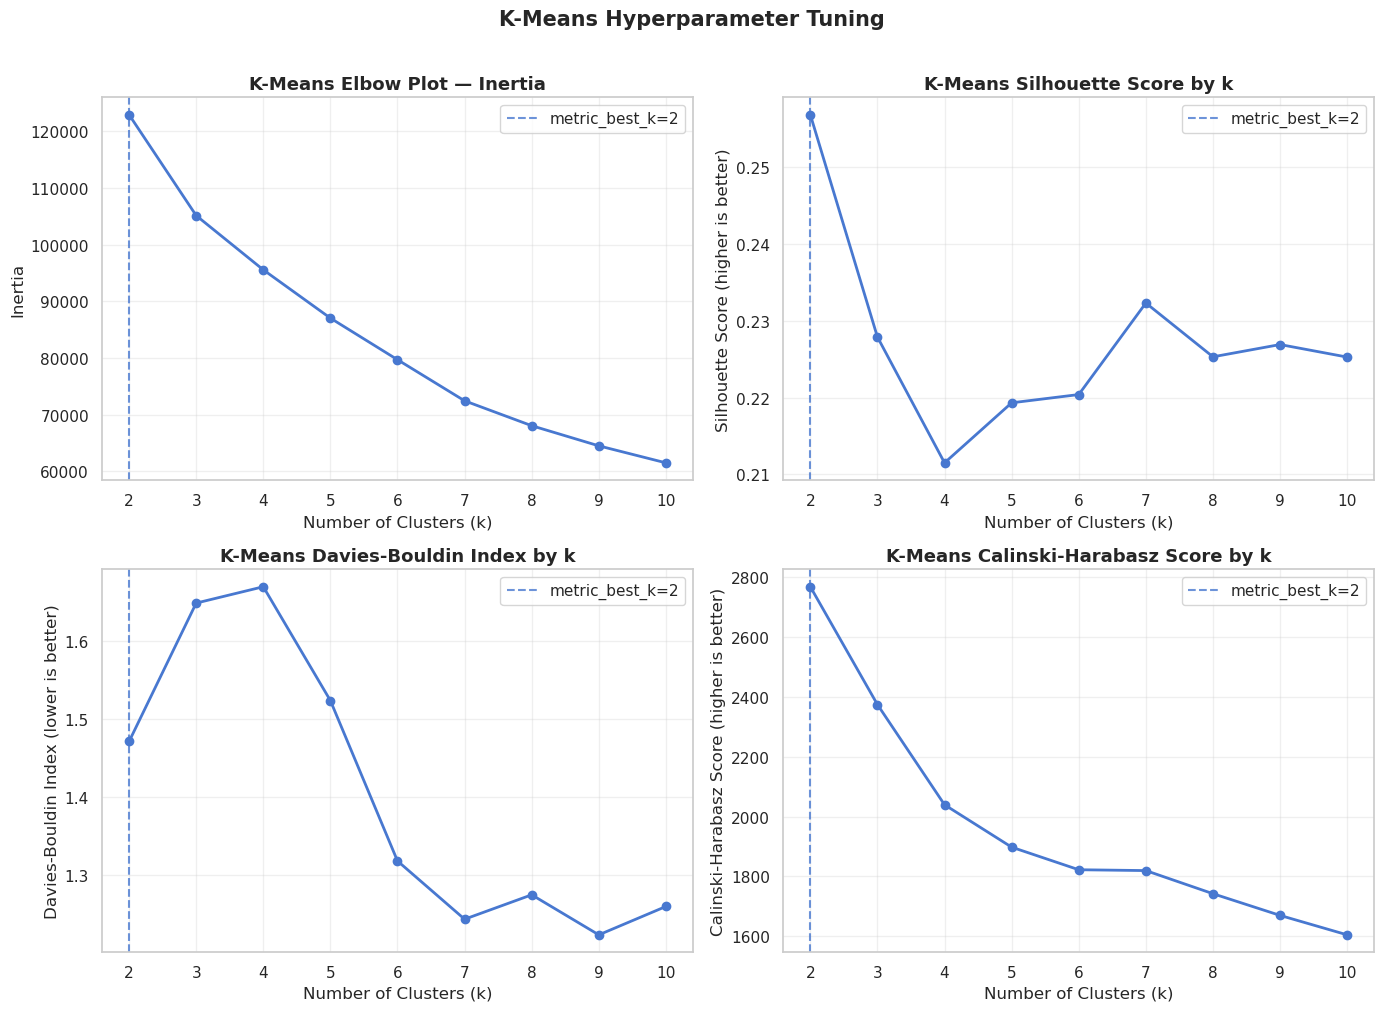

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ks = kmeans_results.index

axes[0, 0].plot(ks, kmeans_results["Inertia"], marker="o", linewidth=2)
axes[0, 0].axvline(metric_best_k_kmeans, linestyle="--", alpha=0.8, label=f"metric_best_k={metric_best_k_kmeans}")
axes[0, 0].set_title("K-Means Elbow Plot — Inertia", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Number of Clusters (k)")
axes[0, 0].set_ylabel("Inertia")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(ks, kmeans_results["Silhouette Score"], marker="o", linewidth=2)
axes[0, 1].axvline(metric_best_k_kmeans, linestyle="--", alpha=0.8, label=f"metric_best_k={metric_best_k_kmeans}")
axes[0, 1].set_title("K-Means Silhouette Score by k", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("Number of Clusters (k)")
axes[0, 1].set_ylabel("Silhouette Score (higher is better)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(ks, kmeans_results["Davies-Bouldin Index"], marker="o", linewidth=2)
axes[1, 0].axvline(metric_best_k_kmeans, linestyle="--", alpha=0.8, label=f"metric_best_k={metric_best_k_kmeans}")
axes[1, 0].set_title("K-Means Davies-Bouldin Index by k", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Number of Clusters (k)")
axes[1, 0].set_ylabel("Davies-Bouldin Index (lower is better)")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(ks, kmeans_results["Calinski-Harabasz Score"], marker="o", linewidth=2)
axes[1, 1].axvline(metric_best_k_kmeans, linestyle="--", alpha=0.8, label=f"metric_best_k={metric_best_k_kmeans}")
axes[1, 1].set_title("K-Means Calinski-Harabasz Score by k", fontsize=13, fontweight="bold")
axes[1, 1].set_xlabel("Number of Clusters (k)")
axes[1, 1].set_ylabel("Calinski-Harabasz Score (higher is better)")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle("K-Means Hyperparameter Tuning", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [31]:
# ── Inspect candidate K-Means solutions k = 3, 4, 5 ──────────────────────
kmeans_candidate_table = build_candidate_table(
    kmeans_results,
    kmeans_labels_by_k,
    df_profile,
    candidates=candidate_k_values,
)

final_selected_k_kmeans, kmeans_candidate_ranking, kmeans_selection_reason = select_interpretable_k(
    kmeans_results,
    kmeans_candidate_table,
    metric_best_k_kmeans,
    prefer_k=4,
)
# --------------------------------------------------------------------
final_selected_k_kmeans = 4
final_selected_k = final_selected_k_kmeans
best_k_kmeans = final_selected_k_kmeans  # Backwards-compatible variable name for later cells

print("K-Means candidate solutions focused on business interpretability:")
display(kmeans_candidate_table.round(4))

print("K-Means candidate ranking:")
display(kmeans_candidate_ranking.round(4))

print(f"metric_best_k_kmeans  = {metric_best_k_kmeans}")
print(f"final_selected_k_kmeans = {final_selected_k_kmeans}")
print(f"final_selected_k = {final_selected_k}")
print(f"Selection reason: {kmeans_selection_reason}")

if metric_best_k_kmeans != final_selected_k_kmeans:
    print(
        "\nThe final K-Means solution intentionally differs from the metric-best k. "
        "This is acceptable in unsupervised learning because internal metrics are diagnostic tools, "
        "not the only decision criterion."
    )

K-Means candidate solutions focused on business interpretability:


,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Inertia,Min Cluster Size,Max Cluster Size,Min Cluster %,Max Cluster %,Profile Separation Score
k,,,,,,,,,
3,0.2279,1.6482,"2,373.8876","105,135.8426",2792,3226,0.3123,0.3609,0.4630
4,0.2115,1.6691,"2,039.4342","95,560.6800",1647,2796,0.1842,0.3128,0.4927
5,0.2193,1.5231,"1,897.9020","87,037.6809",1200,2172,0.1342,0.2430,0.5172


K-Means candidate ranking:


,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Inertia,Min Cluster Size,Max Cluster Size,Min Cluster %,Max Cluster %,Profile Separation Score,Interpretability Score
k,,,,,,,,,,
5,0.2193,1.5231,"1,897.9020","87,037.6809",1200,2172,0.1342,0.2430,0.5172,0.7193
3,0.2279,1.6482,"2,373.8876","105,135.8426",2792,3226,0.3123,0.3609,0.4630,0.4287
4,0.2115,1.6691,"2,039.4342","95,560.6800",1647,2796,0.1842,0.3128,0.4927,0.2495


metric_best_k_kmeans  = 2
final_selected_k_kmeans = 4
final_selected_k = 4
Selection reason: selected because it has the best balanced interpretability score among viable candidates.

The final K-Means solution intentionally differs from the metric-best k. This is acceptable in unsupervised learning because internal metrics are diagnostic tools, not the only decision criterion.


## 2.6b Gaussian Mixture Model Training and Hyperparameter Tuning

For the Gaussian Mixture Model, the number of components plays the role of the number of clusters. The model is evaluated for 2 to 10 components using:

- Silhouette Score,
- Davies-Bouldin Index,
- Calinski-Harabasz Score,
- AIC,
- BIC.

AIC and BIC are useful for evaluating probabilistic model fit and penalizing unnecessary complexity. However, the final segmentation also needs to be interpretable. Therefore, AIC/BIC are considered together with cluster quality metrics, reasonable segment sizes, and candidate profile interpretability.

In [32]:
gmm_records = []
gmm_labels_by_k = {}
gmm_models_by_k = {}

for k in k_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        n_init=5,
    )
    gmm.fit(X_model)
    labels = gmm.predict(X_model)

    gmm_labels_by_k[k] = labels
    gmm_models_by_k[k] = gmm

    metrics = compute_cluster_metrics(X_model, labels)
    metrics["AIC"] = gmm.aic(X_model)
    metrics["BIC"] = gmm.bic(X_model)
    metrics["k"] = k
    gmm_records.append(metrics)

gmm_results = pd.DataFrame(gmm_records).set_index("k")

print("Gaussian Mixture Model metrics for k/components = 2..10:")
display(gmm_results.round(4))

metric_best_k_gmm, gmm_metric_winners = metric_best_from_results(gmm_results)
best_k_gmm_aic = int(gmm_results["AIC"].idxmin())
best_k_gmm_bic = int(gmm_results["BIC"].idxmin())

print("Metric-best GMM diagnostics:")
for metric_name, best_k in gmm_metric_winners.items():
    print(f"  {metric_name:<30}: k = {best_k}")
print(f"  {'Best by AIC':<30}: k = {best_k_gmm_aic}")
print(f"  {'Best by BIC':<30}: k = {best_k_gmm_bic}")
print(f"\n>>> metric_best_k_gmm = {metric_best_k_gmm}")

Gaussian Mixture Model metrics for k/components = 2..10:


,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,AIC,BIC
k,,,,,
2,0.2234,1.6215,"2,336.1876","234,159.8110","235,089.6871"
3,0.2030,2.7074,"1,396.4466","187,027.6254","188,425.9887"
4,0.1586,2.2753,"1,325.8731","148,097.1294","149,963.9799"
5,0.1584,1.8865,"1,233.4184","145,557.7953","147,893.1330"
6,0.1316,2.2638,"1,037.7705","129,704.1828","132,508.0077"
7,0.1103,2.3585,976.8184,"121,536.0190","124,808.3310"
8,0.0994,2.6516,"1,042.6227","112,922.7202","116,663.5195"
9,0.0697,3.0679,795.9832,"101,022.4646","105,231.7511"
10,0.0600,2.3498,844.7022,"95,960.9109","100,638.6846"


Metric-best GMM diagnostics:
  Best by Silhouette            : k = 2
  Best by Davies-Bouldin        : k = 2
  Best by Calinski-Harabasz     : k = 2
  Best by AIC                   : k = 10
  Best by BIC                   : k = 10

>>> metric_best_k_gmm = 2


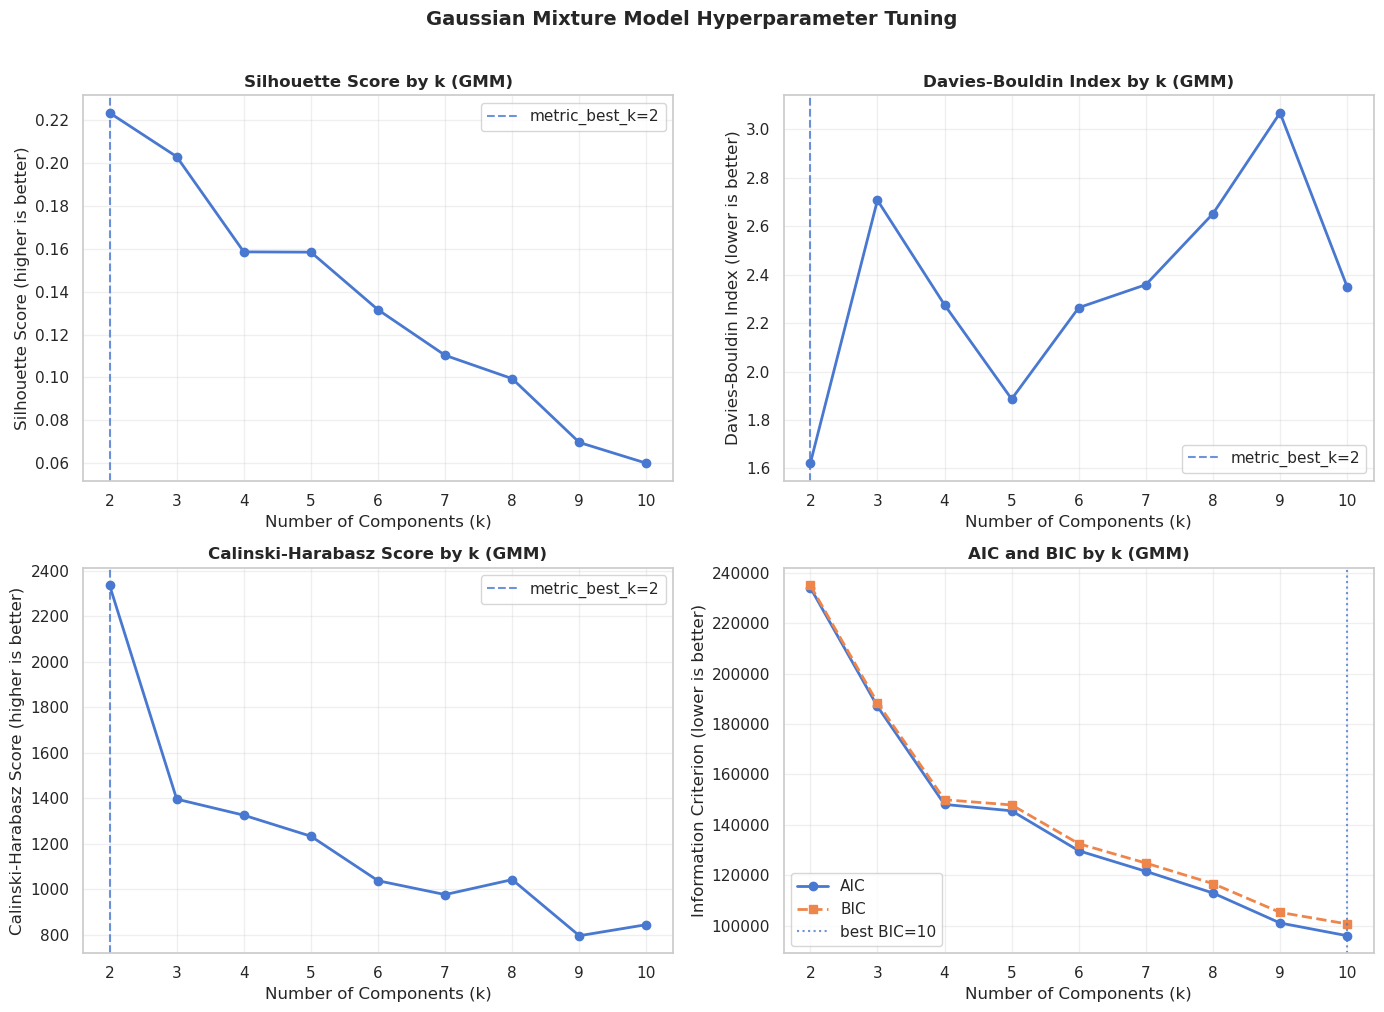

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ks = gmm_results.index

axes[0, 0].plot(ks, gmm_results["Silhouette Score"], marker="o", linewidth=2)
axes[0, 0].axvline(metric_best_k_gmm, linestyle="--", alpha=0.8, label=f"metric_best_k={metric_best_k_gmm}")
axes[0, 0].set_title("Silhouette Score by k (GMM)", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Number of Components (k)")
axes[0, 0].set_ylabel("Silhouette Score (higher is better)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(ks, gmm_results["Davies-Bouldin Index"], marker="o", linewidth=2)
axes[0, 1].axvline(metric_best_k_gmm, linestyle="--", alpha=0.8, label=f"metric_best_k={metric_best_k_gmm}")
axes[0, 1].set_title("Davies-Bouldin Index by k (GMM)", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Number of Components (k)")
axes[0, 1].set_ylabel("Davies-Bouldin Index (lower is better)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(ks, gmm_results["Calinski-Harabasz Score"], marker="o", linewidth=2)
axes[1, 0].axvline(metric_best_k_gmm, linestyle="--", alpha=0.8, label=f"metric_best_k={metric_best_k_gmm}")
axes[1, 0].set_title("Calinski-Harabasz Score by k (GMM)", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Number of Components (k)")
axes[1, 0].set_ylabel("Calinski-Harabasz Score (higher is better)")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(ks, gmm_results["AIC"], marker="o", linewidth=2, label="AIC")
axes[1, 1].plot(ks, gmm_results["BIC"], marker="s", linewidth=2, linestyle="--", label="BIC")
axes[1, 1].axvline(best_k_gmm_bic, linestyle=":", alpha=0.8, label=f"best BIC={best_k_gmm_bic}")
axes[1, 1].set_title("AIC and BIC by k (GMM)", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Number of Components (k)")
axes[1, 1].set_ylabel("Information Criterion (lower is better)")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle("Gaussian Mixture Model Hyperparameter Tuning", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [34]:
# ── Inspect candidate GMM solutions k = 3, 4, 5 ──────────────────────────
gmm_candidate_table = build_candidate_table(
    gmm_results,
    gmm_labels_by_k,
    df_profile,
    candidates=candidate_k_values,
)

# Add a light preference for AIC/BIC within the candidate comparison.
gmm_candidate_table["AIC Rank"] = gmm_candidate_table["AIC"].rank(method="min", ascending=True)
gmm_candidate_table["BIC Rank"] = gmm_candidate_table["BIC"].rank(method="min", ascending=True)

final_selected_k_gmm, gmm_candidate_ranking, gmm_selection_reason = select_interpretable_k(
    gmm_results,
    gmm_candidate_table,
    metric_best_k_gmm,
    prefer_k=4,
)

best_k_gmm = final_selected_k_gmm  # Backwards-compatible variable name for later cells

print("GMM candidate solutions focused on business interpretability:")
display(gmm_candidate_table.round(4))

print("GMM candidate ranking:")
display(gmm_candidate_ranking.round(4))

print(f"metric_best_k_gmm     = {metric_best_k_gmm}")
print(f"best_k_gmm_aic        = {best_k_gmm_aic}")
print(f"best_k_gmm_bic        = {best_k_gmm_bic}")
print(f"final_selected_k_gmm = {final_selected_k_gmm}")
print(f"Selection reason: {gmm_selection_reason}")

if metric_best_k_gmm != final_selected_k_gmm:
    print(
        "\nThe final GMM component count intentionally considers interpretability in addition to "
        "internal clustering metrics and AIC/BIC."
    )

GMM candidate solutions focused on business interpretability:


,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,AIC,BIC,Min Cluster Size,Max Cluster Size,Min Cluster %,Max Cluster %,Profile Separation Score,AIC Rank,BIC Rank
k,,,,,,,,,,,,
3,0.2030,2.7074,"1,396.4466","187,027.6254","188,425.9887",1590,5038,0.1779,0.5635,0.3693,3.0000,3.0000
4,0.1586,2.2753,"1,325.8731","148,097.1294","149,963.9799",1043,3848,0.1167,0.4304,0.4314,2.0000,2.0000
5,0.1584,1.8865,"1,233.4184","145,557.7953","147,893.1330",2,3808,0.0002,0.4260,1.1445,1.0000,1.0000


GMM candidate ranking:


,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,AIC,BIC,Min Cluster Size,Max Cluster Size,Min Cluster %,Max Cluster %,Profile Separation Score,AIC Rank,BIC Rank,Interpretability Score
k,,,,,,,,,,,,,
4,0.1586,2.2753,"1,325.8731","148,097.1294","149,963.9799",1043,3848,0.1167,0.4304,0.4314,2.0000,2.0000,0.6000
3,0.2030,2.7074,"1,396.4466","187,027.6254","188,425.9887",1590,5038,0.1779,0.5635,0.3693,3.0000,3.0000,0.4000


metric_best_k_gmm     = 2
best_k_gmm_aic        = 10
best_k_gmm_bic        = 10
final_selected_k_gmm = 4
Selection reason: k=4 is viable and provides a practical balance between detail and interpretability.

The final GMM component count intentionally considers interpretability in addition to internal clustering metrics and AIC/BIC.


## 2.6c Final Model Training

The final versions of both clustering models are trained using the selected number of clusters/components from the hyperparameter tuning steps.

The resulting labels are stored as:

- `KMEANS_CLUSTER` — hard cluster assignment from K-Means,
- `GMM_CLUSTER` — hard cluster assignment from GMM (highest-probability component).

The variables `metric_best_k` and `final_selected_k` refer to the K-Means solution.

In [35]:
# ── Final K-Means ─────────────────────────────────────────────────────────
metric_best_k = metric_best_k_kmeans
final_selected_k = final_selected_k_kmeans

final_kmeans = KMeans(n_clusters=final_selected_k_kmeans, random_state=42, n_init=20)
kmeans_labels = final_kmeans.fit_predict(X_model)

# ── Final Gaussian Mixture Model ──────────────────────────────────────────
final_gmm = GaussianMixture(
    n_components=final_selected_k_gmm,
    covariance_type='full',
    random_state=42,
    n_init=5,
)
final_gmm.fit(X_model)
gmm_labels = final_gmm.predict(X_model)

print(f'K-Means : metric_best_k={metric_best_k_kmeans}, final_selected_k={final_selected_k_kmeans}, labels={np.unique(kmeans_labels)}')
print(f'GMM     : metric_best_k={metric_best_k_gmm}, final_selected_k={final_selected_k_gmm}, labels={np.unique(gmm_labels)}')

# ── Build combined results DataFrame ──────────────────────────────────────
df_results = df_profile.reset_index(drop=True).copy()
df_results['KMEANS_CLUSTER'] = kmeans_labels
df_results['GMM_CLUSTER'] = gmm_labels

if cust_ids is not None and 'CUST_ID' not in df_results.columns:
    df_results.insert(0, 'CUST_ID', cust_ids.values)

preview_cols = [c for c in ['CUST_ID', 'KMEANS_CLUSTER', 'GMM_CLUSTER'] if c in df_results.columns]
print(f'\nCombined results DataFrame shape: {df_results.shape}')
display(df_results[preview_cols].head(10))


K-Means : metric_best_k=2, final_selected_k=4, labels=[0 1 2 3]
GMM     : metric_best_k=2, final_selected_k=4, labels=[0 1 2 3]

Combined results DataFrame shape: (8940, 23)


,CUST_ID,KMEANS_CLUSTER,GMM_CLUSTER
0,C17342,2,2
1,C13053,0,3
2,C11723,2,1
3,C13717,3,0
4,C11464,2,2
5,C16639,0,3
6,C12687,3,0
7,C11503,2,2
8,C16869,1,0
9,C18000,2,2


## 2.6d Naive Baseline

The **random cluster assignment** baseline assigns each customer to one of *k* clusters uniformly at random, completely ignoring the feature values. Because it learns no structure from the data, it represents a lower-bound comparison.

The baseline uses the same number of clusters as the final selected K-Means solution (`final_selected_k`) so that the comparison is fair.

In [36]:
# ── Random Baseline ───────────────────────────────────────────────────────
rng = np.random.default_rng(seed=42)
random_labels = rng.integers(0, final_selected_k, size=len(X_model))

df_results["RANDOM_BASELINE_CLUSTER"] = random_labels

sil_random = silhouette_score(X_model, random_labels)
db_random = davies_bouldin_score(X_model, random_labels)
ch_random = calinski_harabasz_score(X_model, random_labels)

print("Random Baseline Metrics")
print(f"  Silhouette Score       : {sil_random:.4f}")
print(f"  Davies-Bouldin Index   : {db_random:.4f}")
print(f"  Calinski-Harabasz Score: {ch_random:.4f}")
print(f"  Number of clusters     : {final_selected_k}")

Random Baseline Metrics
  Silhouette Score       : -0.0064
  Davies-Bouldin Index   : 90.5255
  Calinski-Harabasz Score: 1.3879
  Number of clusters     : 4


## 2.7 Model Evaluation and Comparison

The final comparison includes the Random Baseline, K-Means, and Gaussian Mixture Model.

For each model, the table reports:

- final selected number of clusters/components,
- metric-best number of clusters/components,
- Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Score,
- Inertia (K-Means only),
- AIC/BIC (GMM only).

This table is used to compare metric quality alongside the individual model interpretations in Section 2.12.

In [37]:
# ── Compute metrics for all final models ─────────────────────────────────
def get_metrics(X, labels, model_name, final_k, metric_k=None, inertia=None, aic=None, bic=None):
    return {
        'Model': model_name,
        'metric_best_k': metric_k,
        'final_selected_k': final_k,
        'Silhouette Score': silhouette_score(X, labels),
        'Davies-Bouldin Index': davies_bouldin_score(X, labels),
        'Calinski-Harabasz Score': calinski_harabasz_score(X, labels),
        'Inertia': inertia,
        'AIC': aic,
        'BIC': bic,
    }

rows = [
    get_metrics(X_model, random_labels, 'Random Baseline', final_selected_k, metric_k=None),
    get_metrics(X_model, kmeans_labels, 'K-Means',
                final_selected_k_kmeans, metric_k=metric_best_k_kmeans,
                inertia=final_kmeans.inertia_),
    get_metrics(X_model, gmm_labels, 'Gaussian Mixture Model',
                final_selected_k_gmm, metric_k=metric_best_k_gmm,
                aic=final_gmm.aic(X_model), bic=final_gmm.bic(X_model)),
]

model_comparison = pd.DataFrame(rows).set_index('Model')
display(model_comparison.round(4))

best_metric_model = model_comparison.drop(index='Random Baseline')['Silhouette Score'].idxmax()
print(f'Best Silhouette Score: {best_metric_model}')


,metric_best_k,final_selected_k,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Inertia,AIC,BIC
Model,,,,,,,,
Random Baseline,NaN,4,-0.0064,90.5255,1.3879,NaN,NaN,NaN
K-Means,2.0000,4,0.2115,1.6691,"2,039.4342","95,560.6800",NaN,NaN
Gaussian Mixture Model,2.0000,4,0.1586,2.2753,"1,325.8731",NaN,"148,097.1294","149,963.9799"


Best Silhouette Score: K-Means


### Comparison and Model Selection

The table above separates metric-best choices from final selected choices. Internal validation metrics are diagnostic evidence, not a complete decision rule.

**Key interpretation:**

1. The Random Baseline should perform clearly worse than trained models — this confirms real cluster structure in the data.
2. The metric-best k is not automatically the best practical segmentation choice. A k = 2 solution can score very well because it creates the clearest mathematical split, but is too coarse for customer segmentation.
3. K-Means is preferred when metrics are competitive because it is simple, reproducible, and easy to explain. GMM is preferred when its Silhouette Score is substantially higher, indicating its soft, elliptical clusters capture the data structure better.
4. The final model should produce clusters that are large enough to be meaningful, distinct enough to interpret, and useful for business decisions.

In [38]:
# ── Select the final model ────────────────────────────────────────────────
real_models = {
    'K-Means': {
        'labels': kmeans_labels,
        'final_k': final_selected_k_kmeans,
        'metric_k': metric_best_k_kmeans,
    },
    'Gaussian Mixture Model': {
        'labels': gmm_labels,
        'final_k': final_selected_k_gmm,
        'metric_k': metric_best_k_gmm,
    },
}

best_sil_model = model_comparison.drop(index='Random Baseline')['Silhouette Score'].idxmax()
best_sil_value = model_comparison.loc[best_sil_model, 'Silhouette Score']
kmeans_sil = model_comparison.loc['K-Means', 'Silhouette Score']

# Prefer K-Means unless GMM is substantially better (>0.03 Silhouette advantage).
if best_sil_model != 'K-Means' and (best_sil_value - kmeans_sil) > 0.03:
    final_selected_model_name = best_sil_model
    selection_explanation = (
        f'{best_sil_model} was selected because its Silhouette Score was substantially '
        'higher than K-Means while still using an interpretable number of clusters.'
    )
else:
    final_selected_model_name = 'K-Means'
    selection_explanation = (
        'K-Means was selected because its metrics are competitive and its clusters are '
        'easier to interpret as practical customer segments.'
    )

final_labels = real_models[final_selected_model_name]['labels']
final_model_metric_best_k = real_models[final_selected_model_name]['metric_k']
final_model_selected_k = real_models[final_selected_model_name]['final_k']

df_results['FINAL_CLUSTER'] = final_labels

print(f'Final selected model       : {final_selected_model_name}')
print(f'Metric-best k/components   : {final_model_metric_best_k}')
print(f'Final selected k/components: {final_model_selected_k}')
print(f'Reason: {selection_explanation}')

if final_model_metric_best_k != final_model_selected_k:
    print('\nNote: final k differs from metric-best k — this is intentional (interpretability trade-off).')

print('\nFull comparison:')
display(model_comparison.round(4))


Final selected model       : K-Means
Metric-best k/components   : 2
Final selected k/components: 4
Reason: K-Means was selected because its metrics are competitive and its clusters are easier to interpret as practical customer segments.

Note: final k differs from metric-best k — this is intentional (interpretability trade-off).

Full comparison:


,metric_best_k,final_selected_k,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Inertia,AIC,BIC
Model,,,,,,,,
Random Baseline,NaN,4,-0.0064,90.5255,1.3879,NaN,NaN,NaN
K-Means,2.0000,4,0.2115,1.6691,"2,039.4342","95,560.6800",NaN,NaN
Gaussian Mixture Model,2.0000,4,0.1586,2.2753,"1,325.8731",NaN,"148,097.1294","149,963.9799"


### Model Interpretation

Both models are interpreted individually using actual cluster profiles on the original (pre-scaling) dataset. For each model the analysis covers:

- cluster size distribution (bar chart + table),
- PCA scatter plot coloured by cluster,
- cluster profile table (mean values per cluster on original features),
- standardized heatmap of cluster profiles,
- data-driven segment names based on observed cluster means.

Segment names are assigned only when supported by the actual profile values — not by assumption.

### K-Means Clustering — Cluster Interpretation

K-Means — customer count per cluster:


,Customer Count,Share
Cluster,,
0,2213,0.2475
1,1647,0.1842
2,2284,0.2555
3,2796,0.3128


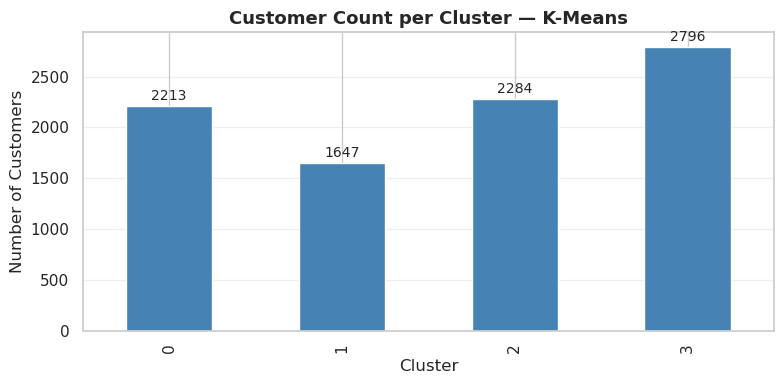

In [39]:
# ── K-Means: Cluster size distribution ───────────────────────────────────
km_cluster_sizes = pd.Series(kmeans_labels, name='Cluster').value_counts().sort_index()
km_size_table = pd.DataFrame({
    'Customer Count': km_cluster_sizes,
    'Share': (km_cluster_sizes / km_cluster_sizes.sum()).round(4),
})
print('K-Means — customer count per cluster:')
display(km_size_table)

fig, ax = plt.subplots(figsize=(8, 4))
km_cluster_sizes.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Customer Count per Cluster — K-Means', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster'); ax.set_ylabel('Number of Customers')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(km_cluster_sizes):
    ax.text(i, v + max(km_cluster_sizes) * 0.01, str(v), ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.show()


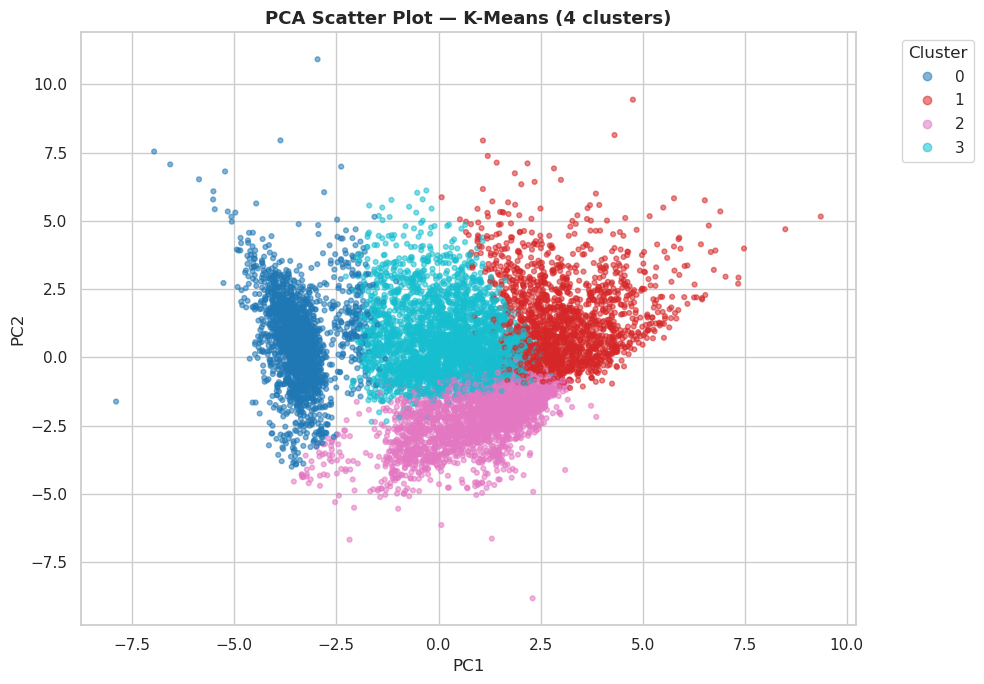

In [40]:
# ── K-Means: PCA scatter plot ─────────────────────────────────────────────
pc1 = X_model.iloc[:, 0]; pc2 = X_model.iloc[:, 1]
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(pc1, pc2, c=kmeans_labels, s=12, alpha=0.55, cmap='tab10')
ax.set_title(f'PCA Scatter Plot — K-Means ({final_selected_k_kmeans} clusters)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(*scatter.legend_elements(), title='Cluster',
          bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(); plt.show()


In [41]:
# ── K-Means: Cluster profile table ───────────────────────────────────────
profile_vars = [
    'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
    'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
    'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
    'TENURE', 'MONTHLY_AVG_SPENDING', 'CREDIT_UTILIZATION', 'PAYMENT_RATIO',
]
profile_vars = [c for c in dict.fromkeys(profile_vars) if c in df_profile.columns]
if len(profile_vars) < 6:
    extra = [c for c in df_profile.select_dtypes('number').columns
             if c not in profile_vars and c.upper() not in {'CUST_ID','CUSTOMER_ID','ID'}]
    profile_vars.extend(extra[:15])

km_profile_df = df_profile[profile_vars].copy().reset_index(drop=True)
km_profile_df['Cluster'] = kmeans_labels
km_cluster_profile = km_profile_df.groupby('Cluster')[profile_vars].mean().round(3)
print('K-Means — mean profile per cluster:')
display(km_cluster_profile)


K-Means — mean profile per cluster:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,MONTHLY_AVG_SPENDING,CREDIT_UTILIZATION,PAYMENT_RATIO
Cluster,,,,,,,,,,,,,,,,,,,,
0,7.1890,0.9040,0.4260,0.3280,0.1100,6.9660,0.0160,0.0090,0.0050,0.2940,7.2120,0.2250,"4,184.1040",6.6200,6.2970,0.0350,11.3740,0.0370,0.0030,1.0700
1,6.8550,0.9830,7.8490,7.0370,6.1350,1.9490,0.9430,0.6380,0.7110,0.0770,2.0250,48.7570,"7,383.8510",7.7400,6.1080,0.2700,11.8750,0.6640,0.0010,1.2970
2,3.4880,0.6650,5.6030,1.8610,4.4550,0.3460,0.5870,0.0700,0.5010,0.0080,0.1120,9.4310,"3,507.7250",5.7090,4.7990,0.3410,11.3590,0.5050,0.0020,1.4860
3,7.1220,0.9670,6.1270,4.3190,3.3720,3.6740,0.5200,0.2060,0.3320,0.1470,3.4010,10.3300,"3,844.1030",6.7180,6.4130,0.0270,11.5490,0.5410,0.0030,1.0650


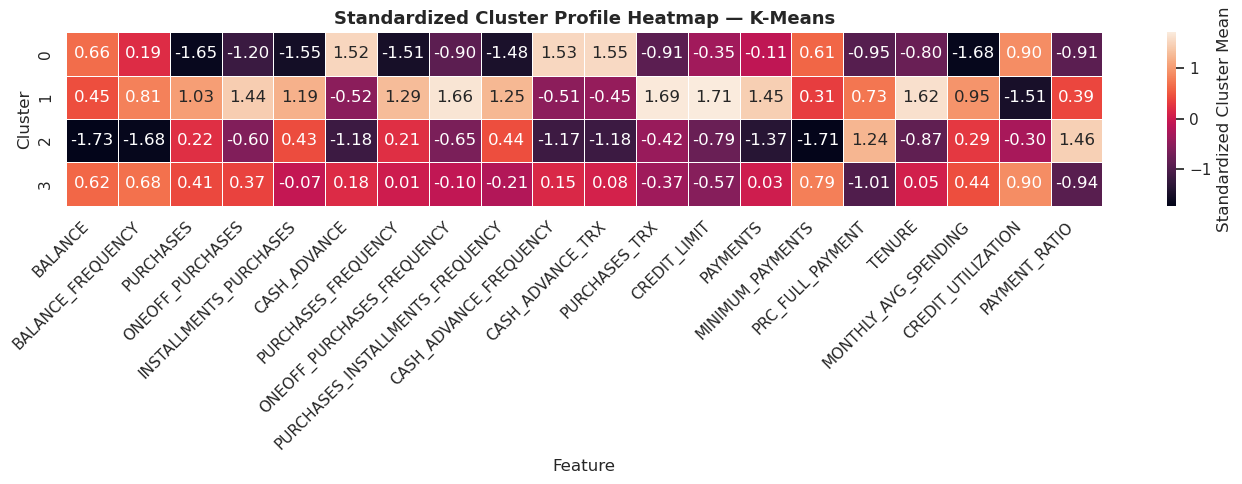

In [42]:
# ── K-Means: Standardized profile heatmap ────────────────────────────────
from sklearn.preprocessing import StandardScaler as _PS
_sc = _PS()
km_profile_scaled = pd.DataFrame(
    _sc.fit_transform(km_cluster_profile),
    index=km_cluster_profile.index, columns=km_cluster_profile.columns
)
fig, ax = plt.subplots(figsize=(max(12, len(profile_vars) * 0.7), 5))
sns.heatmap(km_profile_scaled, annot=True, fmt='.2f', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Standardized Cluster Mean'})
ax.set_title('Standardized Cluster Profile Heatmap — K-Means',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature'); ax.set_ylabel('Cluster')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()


In [43]:
# ── K-Means: Segment interpretation ──────────────────────────────────────
def supported_segment_name(row, zrow):
    high = zrow[zrow >= 0.75].index.tolist()
    very_high = zrow[zrow >= 1.00].index.tolist()
    low = zrow[zrow <= -0.75].index.tolist()
    def has_any(cols): return any(c in high or c in very_high for c in cols)
    def has_low(cols): return any(c in low for c in cols)
    if has_any(['CASH_ADVANCE','CASH_ADVANCE_FREQUENCY','CASH_ADVANCE_TRX']): return 'Cash advance users'
    if has_any(['BALANCE','CREDIT_UTILIZATION','MINIMUM_PAYMENTS']) and not has_any(['PRC_FULL_PAYMENT']): return 'High balance / revolvers'
    if has_any(['PURCHASES','PURCHASES_TRX','MONTHLY_AVG_SPENDING']) and has_any(['CREDIT_LIMIT','PAYMENTS']): return 'High value active customers'
    if has_any(['INSTALLMENTS_PURCHASES','PURCHASES_INSTALLMENTS_FREQUENCY']): return 'Installment-oriented customers'
    if has_any(['ONEOFF_PURCHASES','ONEOFF_PURCHASES_FREQUENCY']): return 'One-off active purchasers'
    if has_any(['PRC_FULL_PAYMENT','PAYMENT_RATIO']) and not has_any(['BALANCE','CASH_ADVANCE']): return 'Responsible payers'
    if has_low(['PURCHASES','PURCHASES_TRX','BALANCE','CASH_ADVANCE']): return 'Low activity customers'
    return 'Mixed behavior customers'

km_segment_labels = {}
km_interp_rows = []
for cid in km_cluster_profile.index:
    zrow = km_profile_scaled.loc[cid]
    name = supported_segment_name(km_cluster_profile.loc[cid], zrow)
    km_segment_labels[cid] = name
    km_interp_rows.append({
        'Cluster': cid, 'Segment Name': name,
        'Customers': int(km_cluster_sizes.loc[cid]),
        'Share': round(km_cluster_sizes.loc[cid] / km_cluster_sizes.sum(), 4),
        'Top High Features': ', '.join([f'{idx}({v:.2f})' for idx,v in zrow.sort_values(ascending=False).head(3).items()]),
        'Top Low Features':  ', '.join([f'{idx}({v:.2f})' for idx,v in zrow.sort_values().head(3).items()]),
    })

km_segment_table = pd.DataFrame(km_interp_rows).set_index('Cluster')
display(km_segment_table)
print('\nK-Means segment names assigned.')
df_results['KMEANS_SEGMENT_NAME'] = pd.Series(kmeans_labels).map(km_segment_labels).values


,Segment Name,Customers,Share,Top High Features,Top Low Features
Cluster,,,,,
0,Cash advance users,2213,0.2475,"CASH_ADVANCE_TRX(1.55), CASH_ADVANCE_FREQUENCY...","MONTHLY_AVG_SPENDING(-1.68), PURCHASES(-1.65),..."
1,High value active customers,1647,0.1842,"CREDIT_LIMIT(1.71), PURCHASES_TRX(1.69), ONEOF...","CREDIT_UTILIZATION(-1.51), CASH_ADVANCE(-0.52)..."
2,Responsible payers,2284,0.2555,"PAYMENT_RATIO(1.46), PRC_FULL_PAYMENT(1.24), P...","BALANCE(-1.73), MINIMUM_PAYMENTS(-1.71), BALAN..."
3,High balance / revolvers,2796,0.3128,"CREDIT_UTILIZATION(0.90), MINIMUM_PAYMENTS(0.7...","PRC_FULL_PAYMENT(-1.01), PAYMENT_RATIO(-0.94),..."



K-Means segment names assigned.


### Gaussian Mixture Model — Cluster Interpretation

GMM — customer count per cluster:


,Customer Count,Share
Cluster,,
0,2261,0.2529
1,1043,0.1167
2,3848,0.4304
3,1788,0.2000


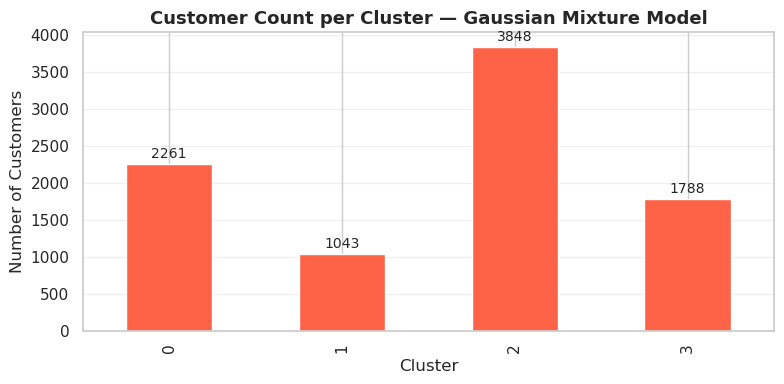

In [44]:
# ── GMM: Cluster size distribution ──────────────────────────────────────
gmm_cluster_sizes = pd.Series(gmm_labels, name='Cluster').value_counts().sort_index()
gmm_size_table = pd.DataFrame({
    'Customer Count': gmm_cluster_sizes,
    'Share': (gmm_cluster_sizes / gmm_cluster_sizes.sum()).round(4),
})
print('GMM — customer count per cluster:')
display(gmm_size_table)

fig, ax = plt.subplots(figsize=(8, 4))
gmm_cluster_sizes.plot(kind='bar', ax=ax, color='tomato')
ax.set_title('Customer Count per Cluster — Gaussian Mixture Model', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster'); ax.set_ylabel('Number of Customers')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(gmm_cluster_sizes):
    ax.text(i, v + max(gmm_cluster_sizes) * 0.01, str(v), ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.show()


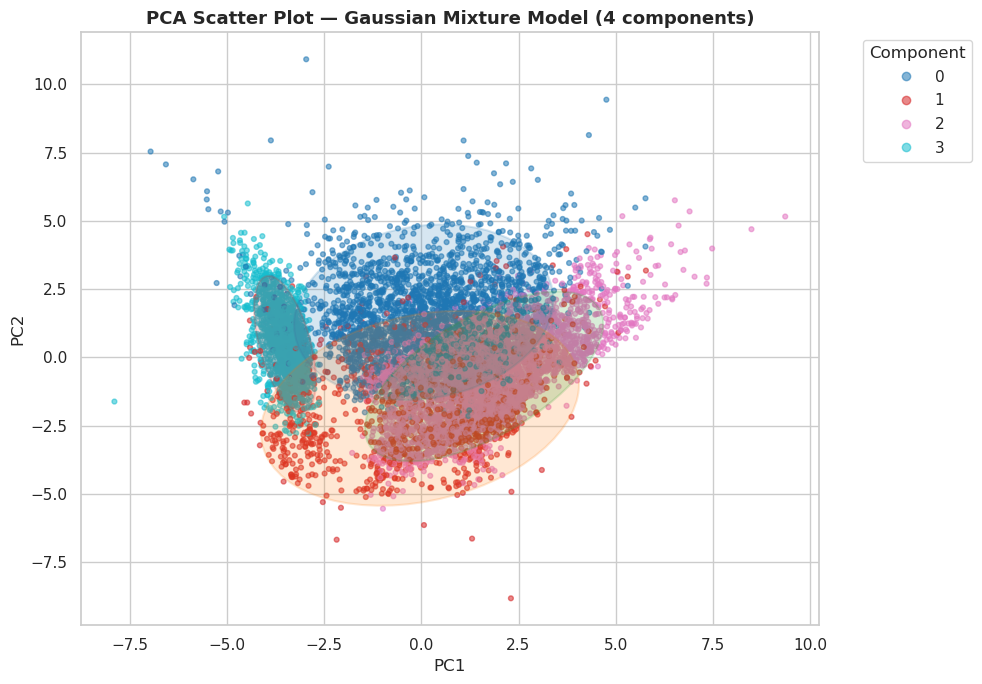

Ellipses show the 2-sigma Gaussian component boundaries in PC1-PC2 space.


In [45]:
# ── GMM: PCA scatter plot ─────────────────────────────────────────────────
pc1 = X_model.iloc[:, 0]; pc2 = X_model.iloc[:, 1]
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(pc1, pc2, c=gmm_labels, s=12, alpha=0.55, cmap='tab10')
ax.set_title(f'PCA Scatter Plot — Gaussian Mixture Model ({final_selected_k_gmm} components)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

# Also show GMM ellipses for the first 2 PCA dimensions to visualise the
# Gaussian components (this is unique to GMM — K-Means cannot do this).
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def draw_ellipse(mean, cov, ax, n_std=2.0, color='black', alpha=0.18):
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx = np.sqrt(1 + pearson); ry = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=rx*2, height=ry*2,
                      facecolor=color, alpha=alpha, edgecolor=color, linewidth=1.5)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    transf = (transforms.Affine2D()
              .rotate_deg(45).scale(scale_x, scale_y)
              .translate(mean[0], mean[1]))
    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)

colors_tab = plt.cm.tab10.colors
for k in range(final_gmm.n_components):
    mean_2d = final_gmm.means_[k, :2]
    cov_2d  = final_gmm.covariances_[k, :2, :2]
    draw_ellipse(mean_2d, cov_2d, ax,
                 color=colors_tab[k % len(colors_tab)], alpha=0.18)

ax.legend(*scatter.legend_elements(), title='Component',
          bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(); plt.show()
print('Ellipses show the 2-sigma Gaussian component boundaries in PC1-PC2 space.')


In [46]:
# ── GMM: Cluster profile table ────────────────────────────────────────────
gmm_profile_df = df_profile[profile_vars].copy().reset_index(drop=True)
gmm_profile_df['Cluster'] = gmm_labels
gmm_cluster_profile = gmm_profile_df.groupby('Cluster')[profile_vars].mean().round(3)
print('GMM — mean profile per cluster/component:')
display(gmm_cluster_profile)


GMM — mean profile per cluster/component:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,MONTHLY_AVG_SPENDING,CREDIT_UTILIZATION,PAYMENT_RATIO
Cluster,,,,,,,,,,,,,,,,,,,,
0,7.5130,0.9820,6.0960,4.5820,3.7460,6.2490,0.5600,0.2610,0.3920,0.2710,7.1670,17.5230,"5,011.3240",7.1250,6.6410,0.0240,11.4070,0.5470,0.0030,1.0900
1,4.1580,0.6210,4.7800,2.7380,3.0710,3.1030,0.4590,0.1510,0.3250,0.0870,1.8160,8.6750,"3,708.7870",4.9560,4.9720,0.2840,10.1750,0.5000,0.0020,1.6470
2,5.3660,0.8600,6.5040,4.0080,4.7500,0.0000,0.6850,0.2750,0.5280,0.0000,0.0000,21.4530,"4,606.8460",6.7190,5.5640,0.2550,12.0000,0.5420,0.0020,1.2360
3,7.3280,0.9310,0.0000,0.0000,0.0000,6.8900,0.0000,0.0000,0.0000,0.2810,6.1300,0.0010,"4,057.2520",6.7610,6.3040,0.0240,11.3990,0.0000,0.0030,1.0840


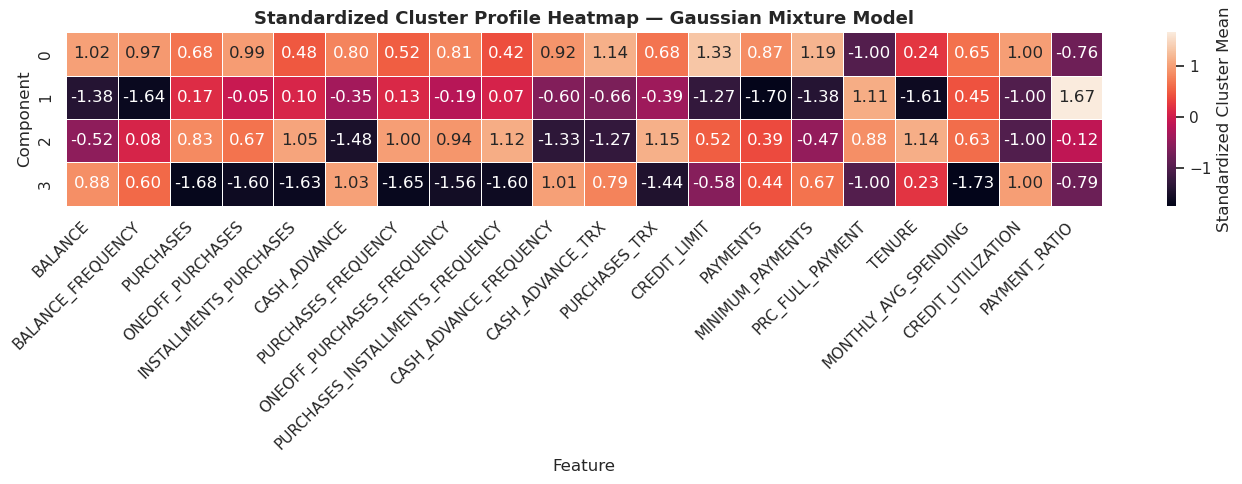

In [47]:
# ── GMM: Standardized profile heatmap ────────────────────────────────────
_sc2 = _PS()
gmm_profile_scaled = pd.DataFrame(
    _sc2.fit_transform(gmm_cluster_profile),
    index=gmm_cluster_profile.index, columns=gmm_cluster_profile.columns
)
fig, ax = plt.subplots(figsize=(max(12, len(profile_vars) * 0.7), 5))
sns.heatmap(gmm_profile_scaled, annot=True, fmt='.2f', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Standardized Cluster Mean'})
ax.set_title('Standardized Cluster Profile Heatmap — Gaussian Mixture Model',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature'); ax.set_ylabel('Component')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()


In [48]:
# ── GMM: Segment interpretation ──────────────────────────────────────────
gmm_segment_labels = {}
gmm_interp_rows = []
for cid in gmm_cluster_profile.index:
    zrow = gmm_profile_scaled.loc[cid]
    name = supported_segment_name(gmm_cluster_profile.loc[cid], zrow)
    gmm_segment_labels[cid] = name
    gmm_interp_rows.append({
        'Component': cid, 'Segment Name': name,
        'Customers': int(gmm_cluster_sizes.loc[cid]),
        'Share': round(gmm_cluster_sizes.loc[cid] / gmm_cluster_sizes.sum(), 4),
        'Top High Features': ', '.join([f'{idx}({v:.2f})' for idx,v in zrow.sort_values(ascending=False).head(3).items()]),
        'Top Low Features':  ', '.join([f'{idx}({v:.2f})' for idx,v in zrow.sort_values().head(3).items()]),
    })

gmm_segment_table = pd.DataFrame(gmm_interp_rows).set_index('Component')
display(gmm_segment_table)
df_results['GMM_SEGMENT_NAME'] = pd.Series(gmm_labels).map(gmm_segment_labels).values

# ── Assign FINAL_SEGMENT_NAME based on the selected final model ───────────
if final_selected_model_name == 'K-Means':
    df_results['FINAL_SEGMENT_NAME'] = df_results['KMEANS_SEGMENT_NAME']
else:
    df_results['FINAL_SEGMENT_NAME'] = df_results['GMM_SEGMENT_NAME']
print(f'FINAL_SEGMENT_NAME assigned from {final_selected_model_name}.')


,Segment Name,Customers,Share,Top High Features,Top Low Features
Component,,,,,
0,Cash advance users,2261,0.2529,"CREDIT_LIMIT(1.33), MINIMUM_PAYMENTS(1.19), CA...","PRC_FULL_PAYMENT(-1.00), PAYMENT_RATIO(-0.76),..."
1,Responsible payers,1043,0.1167,"PAYMENT_RATIO(1.67), PRC_FULL_PAYMENT(1.11), M...","PAYMENTS(-1.70), BALANCE_FREQUENCY(-1.64), TEN..."
2,Installment-oriented customers,3848,0.4304,"PURCHASES_TRX(1.15), TENURE(1.14), PURCHASES_I...","CASH_ADVANCE(-1.48), CASH_ADVANCE_FREQUENCY(-1..."
3,Cash advance users,1788,0.2000,"CASH_ADVANCE(1.03), CASH_ADVANCE_FREQUENCY(1.0...","MONTHLY_AVG_SPENDING(-1.73), PURCHASES(-1.68),..."


FINAL_SEGMENT_NAME assigned from K-Means.


## Export Results

The cluster assignments and the model comparison table are exported to CSV files for further use.

In [49]:
# ── Export 1: Customer-level cluster assignments ──────────────────────────
export_cols = []
if 'CUST_ID' in df_results.columns:
    export_cols.append('CUST_ID')

export_cols += ['KMEANS_CLUSTER', 'GMM_CLUSTER', 'FINAL_CLUSTER',
                'KMEANS_SEGMENT_NAME', 'GMM_SEGMENT_NAME', 'FINAL_SEGMENT_NAME']

df_export = df_results[[c for c in export_cols if c in df_results.columns]].copy()
df_export.to_csv('customer_cluster_assignments.csv', index=False)
print(f'Exported customer_cluster_assignments.csv  ({len(df_export):,} rows)')

# ── Export 2: Model comparison table ──────────────────────────────────────
model_comparison.to_csv('model_comparison_results.csv')
print(f'Exported model_comparison_results.csv  ({model_comparison.shape[0]} models)')


Exported customer_cluster_assignments.csv  (8,940 rows)
Exported model_comparison_results.csv  (3 models)


## 2.8 Result Summary

Our selected models, K-Means and GMM, were trained on 8940 customers using the same prepared dataset. Both models outperformed the random baseline on all metrics, as shown in section 2.7.

The final selected model was K-Means, because it achieved the best scores on all metrics. With Silhouette Score of 0.2115, Davies-Bouldin Index of 1.669 and a Calinksi-Harabasz Score of 2039 it outperformed the GMM model on all three metrics. As the most interpretable number of clusters, we chose k=4, even though the best results were for k=2. Four clusters can tell us more about customers and their segmentation, that is why we went with this decision. It was the best compromise between the metric performance and model interpretability for business purposes. In terms of robustness, K-Means produces stable results across runs thanks to using 20 random initializations and a fixed random seed, while GMM is more sensitive to initialization due to the EM algorithm's dependence on starting conditions.

K-Means won not only in terms of metrics, but also based on the final segmentation. Even though some segments appear similar between the models, the GMM model produces two very similar clusters both labeled as Cash Advance Users. On the other hand, the four K-Means segments capture clear behavioral patterns in the credit card data: 
- High balance / revolvers (31%) carry large balances and make minimum payments; 
- Responsible payers (26%) consistently pay in full; 
- Cash advance users (25%) rely on cash advances rather than purchases; 
- High value active customers (18%) have high credit limits, high purchase volumes, and strong payment behavior.

These profiles are consistent with known credit risk archetypes, which validates the segmentation quality.

